# 02 · Exploratory Data Analysis - MEPS HC-243 (2022)

**Problem under investigation:** can we classify individuals as **high vs. low healthcare spenders** from demographic, health, insurance and socioeconomic characteristics?

This notebook answers the questions that must be settled *before* modelling:

1. What does the target `TOTEXP22` look like, and where should the high-cost threshold be?
2. How is missing information encoded, and how should each pattern be handled?
3. How are the candidate features distributed, and which ones relate to high cost?
4. Which features are redundant, and which ones leak the target?

Every section ends with a **decision**. Figures are saved to `reports/figures/` and tables to `reports/results/`.

In [1]:
import sys, json
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy import stats
from IPython.display import display

from src.data_loader import (
    RESERVED_CODES, MISSING_CODES, SIGNED_INCOME_COLS, TARGET_COL, WEIGHT_COL,
    UTILIZATION_COLS, WEIGHT_DESIGN_COLS, load_raw, analysis_population,
    expenditure_columns, variable_group_map,
)
from src.visualization import (
    SERIES, LOW_COST_COLOR, HIGH_COST_COLOR, INK, INK_SECONDARY, INK_MUTED, SURFACE,
    SEQUENTIAL_BLUE, DIVERGING, apply_style, save_fig, rate_bar,
)

apply_style()
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
RESULTS = ROOT / "reports" / "results"
RESULTS.mkdir(parents=True, exist_ok=True)
money = mtick.FuncFormatter(lambda x, _: f"${x:,.0f}")

In [2]:
raw = load_raw()
df = analysis_population(raw)
print(f"Full file: {raw.shape[0]:,} persons | analysis population (PERWT22F > 0): {df.shape[0]:,} persons")

Full file: 22,431 persons | analysis population (PERWT22F > 0): 21,747 persons


**Analysis population.** The 684 persons with `PERWT22F = 0` have no person-level weight. They belong to responding families but are not part of the documented person-level analytic universe, so they are excluded.

## 1. Candidate features

The EDA focuses on ~40 person-characteristic variables chosen from the documentation's variable groups. For repeated-round variables, the latest round (`53`) or the year-end value (`22`) is used. Expenditure and utilization variables are examined separately in the leakage section.

In [3]:
YES_NO = {1: "Yes", 2: "No"}
HEALTH = {1: "Excellent", 2: "Very good", 3: "Good", 4: "Fair", 5: "Poor"}
LABELS = {
    "SEX": {1: "Male", 2: "Female"},
    "RACETHX": {1: "Hispanic", 2: "NH White", 3: "NH Black", 4: "NH Asian", 5: "NH Other/Multiple"},
    "REGION22": {1: "Northeast", 2: "Midwest", 3: "South", 4: "West"},
    "MARRY22X": {1: "Married", 2: "Widowed", 3: "Divorced", 4: "Separated", 5: "Never married", 6: "Under 16"},
    "HIDEG": {1: "No degree", 2: "GED", 3: "High school", 4: "Bachelor's", 5: "Master's",
              6: "Doctorate", 7: "Other degree", 8: "Under 16"},
    "POVCAT22": {1: "Poor (<100% FPL)", 2: "Near poor", 3: "Low income", 4: "Middle income", 5: "High income"},
    "INSCOV22": {1: "Any private", 2: "Public only", 3: "Uninsured"},
    "RTHLTH53": HEALTH, "MNHLTH53": HEALTH,
    "EMPST53": {1: "Employed", 2: "Job to return to", 3: "Job during round", 4: "Not employed"},
    "OFTSMK53": {1: "Every day", 2: "Some days", 3: "Not at all"},
    "HAVEUS42": YES_NO, "BORNUSA": YES_NO,
}

NUMERIC = {"AGE22X": "Age (12/31/22)", "FAMINC22": "Family income ($)", "POVLEV22": "Income as % of poverty line",
           "TTLP22X": "Personal income ($)", "FAMSZE22": "Family size", "ADBMI42": "Adult BMI",
           "K6SUM42": "K6 psychological distress", "PHQ242": "PHQ-2 depression score",
           "DDNWRK22": "Work days missed"}
NOMINAL = {"SEX": "Sex", "RACETHX": "Race/ethnicity", "REGION22": "Region", "MARRY22X": "Marital status",
           "HIDEG": "Highest degree", "INSCOV22": "Insurance coverage", "EMPST53": "Employment status",
           "HAVEUS42": "Has usual source of care", "BORNUSA": "Born in USA"}
ORDINAL = {"POVCAT22": "Poverty category", "RTHLTH53": "Perceived physical health",
           "MNHLTH53": "Perceived mental health", "OFTSMK53": "Smoking frequency"}
CONDITIONS = {"HIBPDX": "High blood pressure", "CHDDX": "Coronary heart disease", "ANGIDX": "Angina",
              "MIDX": "Heart attack", "OHRTDX": "Other heart disease", "STRKDX": "Stroke",
              "EMPHDX": "Emphysema", "CHOLDX": "High cholesterol", "CANCERDX": "Cancer",
              "DIABDX_M18": "Diabetes", "ARTHDX": "Arthritis", "ASTHDX": "Asthma", "ADHDADDX": "ADHD (children)"}
LIMITATIONS = {"ACTLIM31": "Activity limitation", "WLKLIM31": "Walking limitation",
               "COGLIM31": "Cognitive limitation", "ADLHLP31": "Needs help with ADLs",
               "IADLHP31": "Needs help with IADLs"}
INSURANCE_FLAGS = {"MCARE22": "Medicare (any in 2022)", "MCAID22": "Medicaid (any in 2022)",
                   "UNINS22": "Uninsured all year"}
FLAGS = {**CONDITIONS, **LIMITATIONS, **INSURANCE_FLAGS}

CANDIDATES = {**NUMERIC, **NOMINAL, **ORDINAL, **FLAGS}
print(f"{len(CANDIDATES)} candidate features: {len(NUMERIC)} numeric, {len(NOMINAL)} nominal, "
      f"{len(ORDINAL)} ordinal, {len(FLAGS)} yes/no flags")

43 candidate features: 9 numeric, 9 nominal, 4 ordinal, 21 yes/no flags


## 2. Target analysis: `TOTEXP22`

`TOTEXP22` is total 2022 healthcare **payments** from all sources (out of pocket, private insurance, Medicare, Medicaid and others). It is not billed charges.

In [4]:
t = df[TARGET_COL]
target_summary = pd.Series({
    "count": len(t), "mean": t.mean(), "median": t.median(), "std": t.std(),
    "min": t.min(), "Q1 (25%)": t.quantile(.25), "Q3 (75%)": t.quantile(.75),
    "P80": t.quantile(.80), "P90": t.quantile(.90), "P95": t.quantile(.95), "P99": t.quantile(.99),
    "max": t.max(), "skewness": t.skew(), "kurtosis": t.kurt(),
    "zero spend (%)": (t == 0).mean() * 100,
    "skewness of log1p": np.log1p(t).skew(),
    "skewness of log (non-zero)": np.log(t[t > 0]).skew(),
}).round(2)
target_summary.to_csv(RESULTS / "eda_target_summary.csv", header=["value"])
display(target_summary.to_frame("TOTEXP22"))

,TOTEXP22
count,21747.00
mean,7780.26
median,1679.00
std,23244.20
min,0.00
Q1 (25%),291.00
Q3 (75%),6615.00
P80,8913.60
P90,19180.20
P95,34375.90


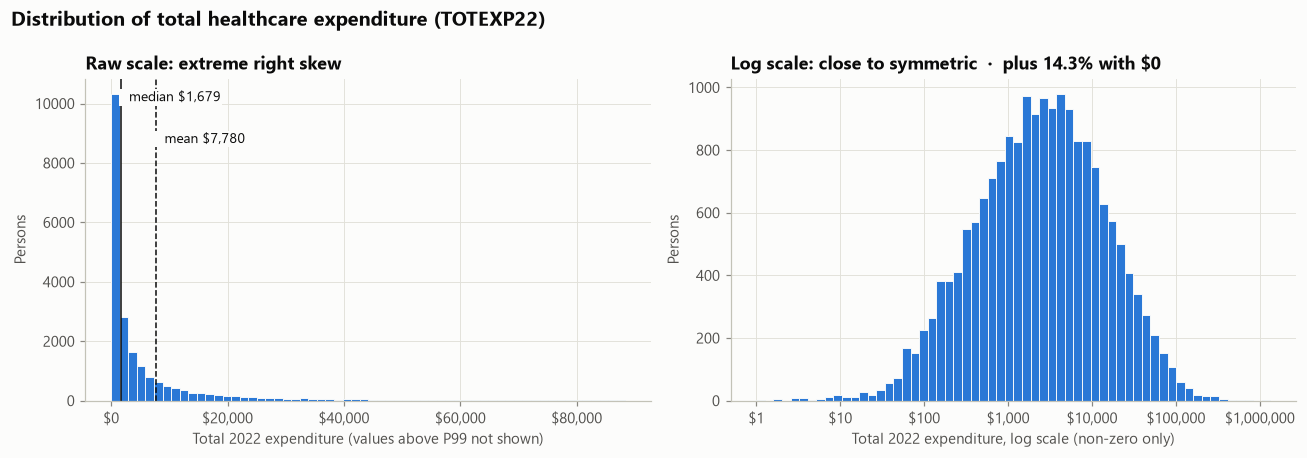

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

ax = axes[0]
p99 = t.quantile(.99)
ax.hist(t[t <= p99], bins=60, color=LOW_COST_COLOR, edgecolor=SURFACE, linewidth=0.6)
for val, name, ls, frac in [(t.median(), "median", "-", 0.93), (t.mean(), "mean", "--", 0.80)]:
    ax.axvline(val, color=INK, linewidth=1, linestyle=ls)
    ax.text(val, ax.get_ylim()[1] * frac, f"  {name} ${val:,.0f}", color=INK, fontsize=9,
            bbox=dict(facecolor=SURFACE, edgecolor="none", pad=1))
ax.xaxis.set_major_formatter(money)
ax.set_xlabel("Total 2022 expenditure (values above P99 not shown)")
ax.set_ylabel("Persons")
ax.set_title("Raw scale: extreme right skew")

ax = axes[1]
ax.hist(np.log10(t[t > 0]), bins=60, color=LOW_COST_COLOR, edgecolor=SURFACE, linewidth=0.6)
ax.set_xlabel("Total 2022 expenditure, log scale (non-zero only)")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${10**x:,.0f}"))
ax.set_title(f"Log scale: close to symmetric  ·  plus {(t == 0).mean():.1%} with $0")
ax.set_ylabel("Persons")

fig.suptitle("Distribution of total healthcare expenditure (TOTEXP22)", x=0.01, ha="left",
             fontsize=13, fontweight="bold")
fig.tight_layout()
save_fig(fig, "02_target_distribution")
plt.show()

#### 📖 What this chart shows (in plain English)
This shows how much money people spent on healthcare in 2022 (`TOTEXP22`).

**Left chart (normal dollar scale):** almost everyone is squeezed into the first bar near $0, and a thin tail stretches to the right. Most people spend a little, and a few spend a lot. The **median** (the middle person) spent **$1,679**. The **mean** (average) is much higher at **$7,780**, because a few very expensive patients pull the average up.

**Right chart (log scale):** each step on the x-axis is 10 times bigger ($10 → $100 → $1,000). On this scale the data forms a neat bell shape. This view does not include the **14.3% of people who spent $0**.

**What it means for us:** spending is very uneven. We should not judge "high" or "low" by the average. Later, when predicting the exact dollar amount, a log scale will work much better.

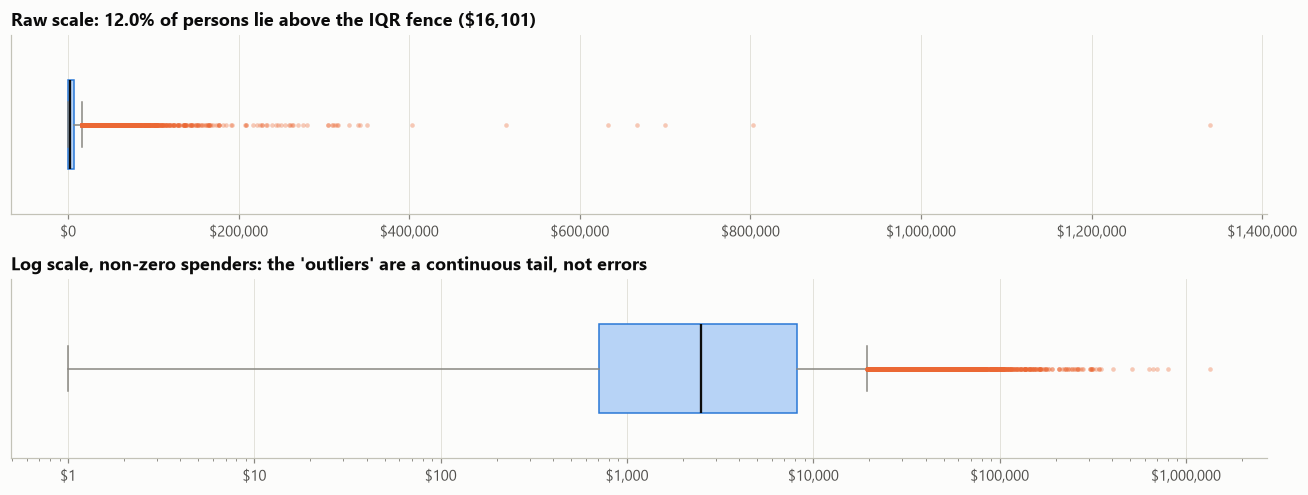

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(12, 4.6))
box_style = dict(patch_artist=True, orientation="horizontal", widths=0.5,
                 boxprops=dict(facecolor="#b7d3f6", edgecolor=LOW_COST_COLOR),
                 medianprops=dict(color=INK, linewidth=1.5),
                 whiskerprops=dict(color=INK_MUTED), capprops=dict(color=INK_MUTED),
                 flierprops=dict(marker="o", markersize=3, markerfacecolor=HIGH_COST_COLOR,
                                 markeredgecolor="none", alpha=0.35))
q1, q3 = t.quantile([.25, .75])
fence = q3 + 1.5 * (q3 - q1)

axes[0].boxplot(t, **box_style)
axes[0].xaxis.set_major_formatter(money)
axes[0].set_yticks([])
axes[0].set_title(f"Raw scale: {(t > fence).mean():.1%} of persons lie above the IQR fence (${fence:,.0f})")

axes[1].boxplot(t[t > 0], **box_style)
axes[1].set_xscale("log")
axes[1].xaxis.set_major_formatter(money)
axes[1].set_yticks([])
axes[1].set_title("Log scale, non-zero spenders: the 'outliers' are a continuous tail, not errors")
fig.tight_layout()
save_fig(fig, "03_target_boxplot")
plt.show()

#### 📖 What this chart shows (in plain English)
A **boxplot** summarises a distribution. The box holds the middle 50% of people, the black line is the median, and the dots are "outliers": values far above the rest.

**Top (normal scale):** the box is so thin it is almost invisible at the far left. The orange dots stretch all the way to **$1.3 million**. A standard statistical rule marks **12% of people** (everyone above $16,101) as outliers.

**Bottom (log scale, people who spent something):** the "outliers" do not stand apart from the rest. They continue smoothly from the box.

**What it means for us:** these are **not mistakes** in the data. They are real people with serious illnesses, and they are exactly the "high-cost" group we want to find. **We will not delete them.**

The IQR rule flags ~12% of people as outliers, but these are **real high spenders**, the very group this project wants to identify. They are not data errors and will **not** be removed.

### Where does the spending go?

,top_pct_of_people,pct_of_total_spending
0,1,20.7
1,5,47.5
2,10,63.8
3,20,80.6
4,50,97.0


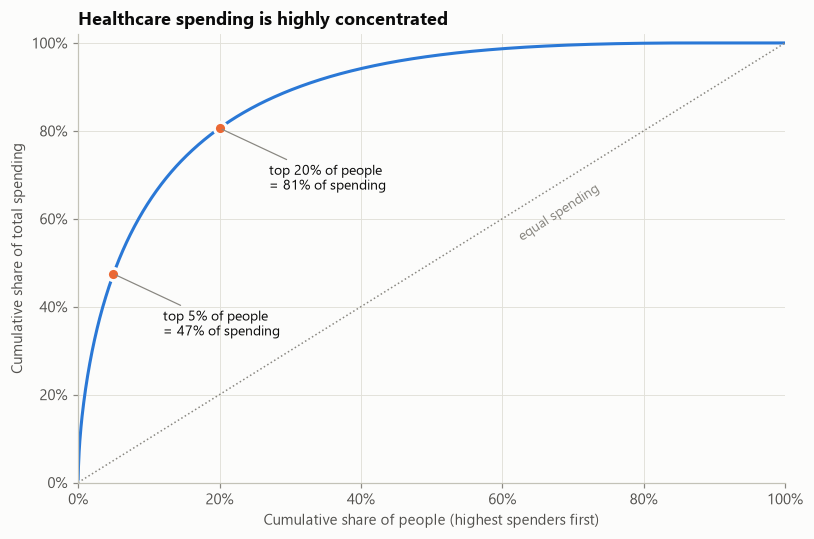

In [7]:
s = np.sort(t.to_numpy())[::-1]
cum_people = np.arange(1, len(s) + 1) / len(s) * 100
cum_spend = np.cumsum(s) / s.sum() * 100

concentration = pd.DataFrame({
    "top_pct_of_people": [1, 5, 10, 20, 50],
    "pct_of_total_spending": [round(s[: int(len(s) * p / 100)].sum() / s.sum() * 100, 1) for p in [1, 5, 10, 20, 50]],
})
concentration.to_csv(RESULTS / "eda_spending_concentration.csv", index=False)
display(concentration)

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(cum_people, cum_spend, color=LOW_COST_COLOR)
ax.plot([0, 100], [0, 100], color=INK_MUTED, linewidth=1, linestyle=":")
ax.text(62, 55, "equal spending", color=INK_MUTED, fontsize=9, rotation=33)
for p in [5, 20]:
    y = np.interp(p, cum_people, cum_spend)
    ax.plot([p], [y], "o", color=HIGH_COST_COLOR, markersize=8, markeredgecolor=SURFACE, markeredgewidth=2)
    ax.annotate(f"top {p}% of people\n= {y:.0f}% of spending", (p, y), xytext=(p + 7, y - 14),
                fontsize=9, color=INK, arrowprops=dict(arrowstyle="-", color=INK_MUTED, lw=0.8))
ax.set_xlim(0, 100); ax.set_ylim(0, 102)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel("Cumulative share of people (highest spenders first)")
ax.set_ylabel("Cumulative share of total spending")
ax.set_title("Healthcare spending is highly concentrated")
fig.tight_layout()
save_fig(fig, "04_spending_concentration")
plt.show()

#### 📖 What this chart shows (in plain English)
This line answers the question: *"What share of all healthcare money is spent by the most expensive people?"*

**How to read it:** go along the bottom to a share of people (sorted from highest spender to lowest), then read up to see their share of total spending. The dotted diagonal is what a perfectly equal world would look like, where everyone spends the same.

- The top **5%** of people spend **47%** of all the money.
- The top **20%** of people spend **81%** of all the money.

**What it means for us:** this is the classic **80/20 rule**. It gives us a clear, easy-to-defend way to define "high cost": the **top 20% of spenders**. That is where most of the money goes, so it is the group most worth predicting.

### Choosing the classification threshold

In [8]:
rows = []
for q in [0.50, 0.75, 0.80, 0.90, 0.95]:
    thr = t.quantile(q)
    hi = t >= thr
    rows.append({"percentile": f"P{int(q*100)}", "threshold_$": round(thr),
                 "pct_high_cost": round(hi.mean() * 100, 1), "n_high_cost": int(hi.sum()),
                 "pct_of_spending_held": round(t[hi].sum() / t.sum() * 100, 1)})
thresholds = pd.DataFrame(rows)
thresholds.to_csv(RESULTS / "eda_threshold_options.csv", index=False)
display(thresholds)

,percentile,threshold_$,pct_high_cost,n_high_cost,pct_of_spending_held
0,P50,1679,50.0,10874,97.0
1,P75,6615,25.0,5437,85.6
2,P80,8914,20.0,4350,80.6
3,P90,19180,10.0,2175,63.8
4,P95,34376,5.0,1088,47.5


| Option | Verdict |
|---|---|
| P50 (median) | Balanced classes, but "above median" (~$1.7K) is not meaningfully *high* cost |
| P75 | Reasonable, but the split has no clear rationale |
| **P80** | **Chosen.** The top 20% hold ~80% of all spending (a Pareto split). ~4,350 positives, 80/20 imbalance is manageable |
| P90 / P95 | Sharper definition of high cost, but only 2,175 / 1,090 positives and strong imbalance. Kept as a stretch experiment |

> **Decision (target):** `HIGH_COST = 1 if TOTEXP22 >= P80 else 0`.
> In the modelling notebooks the P80 cut-off is computed **on the training split only** and then applied to the test split, so the test data never influences the target definition. On the full analysis population it is ≈ $8,900.

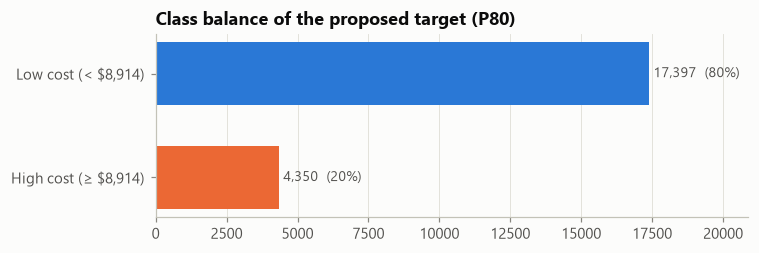

In [9]:
THRESHOLD_Q = 0.80
threshold = t.quantile(THRESHOLD_Q)
df["HIGH_COST"] = (t >= threshold).astype(int)
overall_rate = df["HIGH_COST"].mean() * 100

counts = df["HIGH_COST"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7, 2.4))
ax.barh([0, 1], counts.values, color=[LOW_COST_COLOR, HIGH_COST_COLOR], height=0.6)
ax.set_yticks([0, 1], [f"Low cost (< ${threshold:,.0f})", f"High cost (≥ ${threshold:,.0f})"])
for i, n in enumerate(counts.values):
    ax.text(n + 150, i, f"{n:,}  ({n / counts.sum():.0%})", va="center", fontsize=9, color=INK_SECONDARY)
ax.set_xlim(0, counts.max() * 1.2)
ax.grid(axis="y", visible=False)
ax.invert_yaxis()
ax.set_title("Class balance of the proposed target (P80)")
fig.tight_layout()
save_fig(fig, "05_class_balance")
plt.show()

#### 📖 What this chart shows (in plain English)
After drawing the line at the 80th percentile (**$8,914**), this is how many people land in each group:

- **Low cost:** 17,397 people (80%)
- **High cost:** 4,350 people (20%)

**What it means for us:** the two groups are **unequal (imbalanced)**. A lazy model that always guesses "low cost" would be right 80% of the time and still be useless. So we will judge models by how well they **find the high-cost people** (recall, F1, ROC-AUC), not by plain accuracy. We may also tell the models to pay extra attention to the smaller group (class weights).

## 3. Missing values and reserved codes

`isnull()` reports **zero** missing cells, because MEPS encodes missing information as negative codes. The analysis therefore uses the codes directly and separates:

- **`-1` Inapplicable**: skipped *by design*. This is structural and informative.
- **`-7 / -8 / -15`**: asked, but no usable answer. This is true missingness.
- **`-2`**: answer carried over from a previous round (employment section).

,Valid,Inapplicable (-1),Previous round (-2),Missing (-7/-8/-15),other codes
group,,,,,
Priority conditions,30.2,69.6,0.0,0.2,-0.0
Employment,31.4,57.2,10.5,0.9,0.0
Disability days,31.9,58.5,0.0,9.6,0.0
Health status,35.7,63.5,0.0,0.7,0.0
Access to care,65.5,31.3,0.0,3.2,0.0
Demographics,79.2,20.8,0.0,0.0,0.0
Income & tax,88.2,11.4,0.0,0.4,0.0
Health insurance,97.4,2.4,0.0,0.1,-0.0
Survey admin / IDs,99.4,0.6,0.0,0.0,0.0


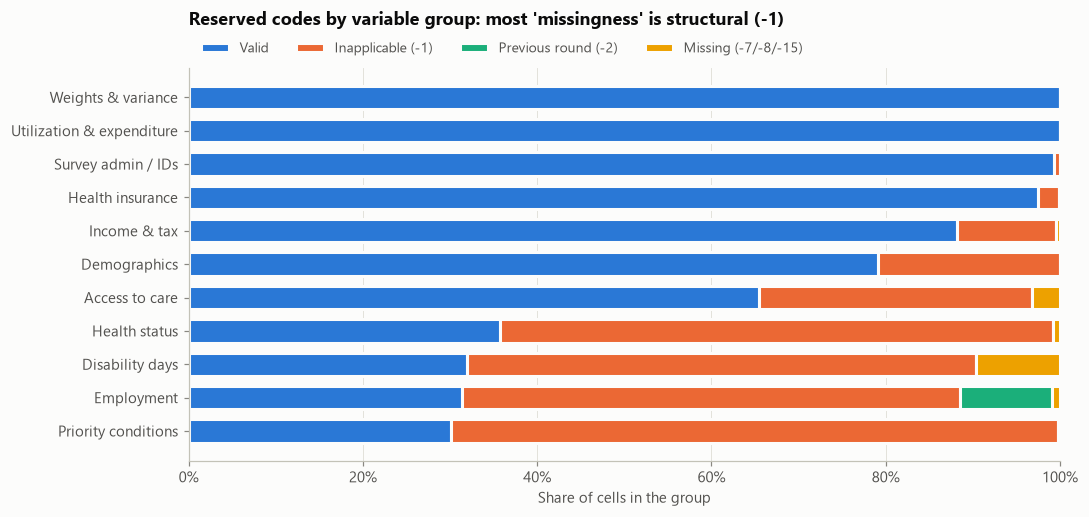

In [10]:
num = df.select_dtypes("number").drop(columns=SIGNED_INCOME_COLS + ["HIGH_COST"])
groups = pd.Series(variable_group_map(raw.columns.tolist()))
cell_share = []
for g, cols in groups.groupby(groups).groups.items():
    block = num[[c for c in cols if c in num.columns]].to_numpy()
    cell_share.append({"group": g, "Valid": np.mean(block >= 0) * 100,
                       "Inapplicable (-1)": np.mean(block == -1) * 100,
                       "Previous round (-2)": np.mean(block == -2) * 100,
                       "Missing (-7/-8/-15)": np.isin(block, MISSING_CODES).mean() * 100})
cell_share = pd.DataFrame(cell_share).set_index("group").sort_values("Valid")
cell_share["other codes"] = 100 - cell_share.sum(axis=1)
display(cell_share.round(1))

fig, ax = plt.subplots(figsize=(10, 4.8))
left = np.zeros(len(cell_share))
for col, color in zip(["Valid", "Inapplicable (-1)", "Previous round (-2)", "Missing (-7/-8/-15)"], SERIES):
    ax.barh(cell_share.index, cell_share[col], left=left, color=color, label=col,
            edgecolor=SURFACE, linewidth=2, height=0.7)
    left += cell_share[col].to_numpy()
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlim(0, 100)
ax.grid(axis="y", visible=False)
ax.set_xlabel("Share of cells in the group")
ax.legend(ncol=4, loc="lower left", bbox_to_anchor=(0, 1.0), fontsize=9)
ax.set_title("Reserved codes by variable group: most 'missingness' is structural (-1)", pad=28)
fig.tight_layout()
save_fig(fig, "01a_reserved_codes_by_group")
plt.show()

#### 📖 What this chart shows (in plain English)
Each bar is one group of columns in the dataset, for example "Employment" or "Health insurance". The bar is split by what kind of values the cells hold:

- **Blue:** a real answer.
- **Orange (-1):** the question was **not asked** to this person on purpose. For example, a 5-year-old is not asked about their job.
- **Green (-2):** the answer was already given in an earlier interview.
- **Yellow:** the person refused or didn't know. This is the only *truly* missing data.

**How to read it:** the more orange a bar has, the more of that group's questions were skipped by design.

**What it means for us:** almost all the "missing" data is orange. It isn't lost information; it follows the survey's rules, such as children being skipped for adult questions. So we must **not** fill these gaps with averages. Real missing answers (yellow) are very rare.

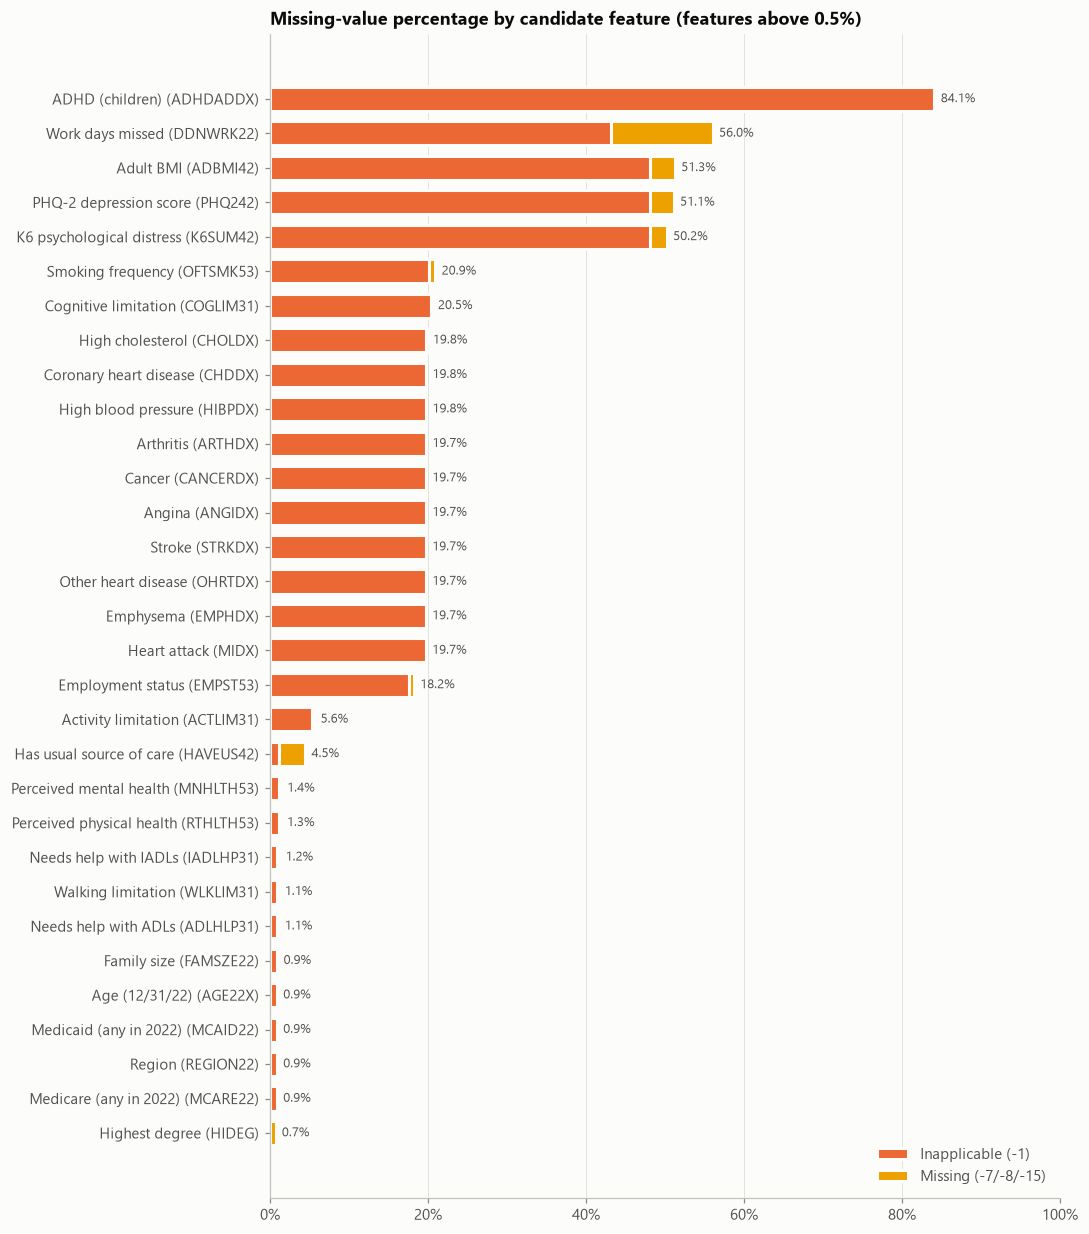

In [11]:
rows = []
for c, label in CANDIDATES.items():
    v = df[c]
    if c in SIGNED_INCOME_COLS:
        inapp, miss = 0.0, v.isin([-15]).mean() * 100
    else:
        inapp, miss = (v == -1).mean() * 100, v.isin(MISSING_CODES).mean() * 100
    rows.append({"feature": c, "label": label, "pct_inapplicable": inapp, "pct_missing": miss})
cand_missing = pd.DataFrame(rows).set_index("feature")
cand_missing["pct_total"] = cand_missing.pct_inapplicable + cand_missing.pct_missing
cand_missing = cand_missing.sort_values("pct_total", ascending=False)
cand_missing.round(2).to_csv(RESULTS / "eda_candidate_missingness.csv")

show = cand_missing[cand_missing.pct_total > 0.5]
fig, ax = plt.subplots(figsize=(10, 0.32 * len(show) + 1.4))
ylab = [f"{r.label} ({i})" for i, r in show.iterrows()]
ax.barh(ylab, show.pct_inapplicable, color=SERIES[1], label="Inapplicable (-1)",
        edgecolor=SURFACE, linewidth=2, height=0.7)
ax.barh(ylab, show.pct_missing, left=show.pct_inapplicable, color=SERIES[3],
        label="Missing (-7/-8/-15)", edgecolor=SURFACE, linewidth=2, height=0.7)
for y, total in enumerate(show.pct_total):
    ax.text(total + 0.8, y, f"{total:.1f}%", va="center", fontsize=8.5, color=INK_SECONDARY)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlim(0, 100)
ax.grid(axis="y", visible=False)
ax.legend(loc="lower right")
ax.set_title("Missing-value percentage by candidate feature (features above 0.5%)")
fig.tight_layout()
save_fig(fig, "01b_missing_by_candidate_feature")
plt.show()

#### 📖 What this chart shows (in plain English)
This chart zooms in on the **features we might use in the model**. Each bar shows what percent of people have no usable value for that feature.

- **Orange:** not asked (skipped on purpose).
- **Yellow:** asked, but refused or didn't know.

**How to read it:** longer bars mean more people without an answer.

**What it means for us:**
- **ADHD (84%)**, **work days missed (56%)**, and **BMI / depression / distress scores (~50%)** are missing for too many people. We will **drop** them.
- The heart, cancer and diabetes questions are empty for about **20%** of people. Those people are almost all **children**, who were never asked. We keep these features and add a "not asked (child)" category.
- Everything else is almost complete (under 5% missing).

Where does the `-1` come from? The same few skip patterns explain almost all of it:

In [12]:
age = df["AGE22X"]
checks = {
    "Condition flags (e.g. HIBPDX) = -1": df["HIBPDX"] == -1,
    "SAQ items (ADBMI42 / K6SUM42) = -1": df["K6SUM42"] == -1,
    "ADHDADDX = -1": df["ADHDADDX"] == -1,
    "EMPST53 = -1": df["EMPST53"] == -1,
    "AGE22X / REGION22 = -1": df["AGE22X"] == -1,
}
for name, mask in checks.items():
    a = df.loc[mask, "AGELAST"]
    print(f"{name:40} n={mask.sum():6,}  AGELAST range {a.min():>3}–{a.max():<3}  share under 18: {(a < 18).mean():.0%}")

Condition flags (e.g. HIBPDX) = -1       n= 4,279  AGELAST range   0–85   share under 18: 97%
SAQ items (ADBMI42 / K6SUM42) = -1       n=10,448  AGELAST range   0–85   share under 18: 40%
ADHDADDX = -1                            n=18,290  AGELAST range   0–85   share under 18: 5%
EMPST53 = -1                             n= 3,817  AGELAST range   0–85   share under 18: 95%
AGE22X / REGION22 = -1                   n=   188  AGELAST range  13–85   share under 18: 1%


| Pattern | Cause | Handling decision |
|---|---|---|
| Adult condition flags `-1` (~19.7%) | Asked of adults only, so these are almost all children | Keep `-1` as its own **"not asked (child)"** category, never impute a diagnosis |
| SAQ items (BMI, K6, PHQ-2) ~51% `-1/-15` | Self-Administered Questionnaire: adults who returned it | **Drop** from the main model. Too sparse, and the pattern depends on SAQ response |
| `ADHDADDX` 84% `-1` | Asked for children only | **Drop** |
| `DDNWRK22` ~56% `-1/-15` | Workers only, and often not computable | **Drop** |
| `EMPST53` ~18% `-1` | Under 16 | Keep. Treat `-1` as its own employment category |
| `AGE22X`, `REGION22`, `MCARE22`… 0.9% `-1` | Not in scope on 31 Dec 2022 (died or institutionalized) | Keep. Use `AGELAST` for age and add an **out-of-scope flag** (see below) |
| `-7/-8/-15` (<3% each) | Refused or don't know | Impute on the training data (mode for categories, median for numbers) |

In [13]:
oos = df["REGION22"] == -1
print(f"Out of scope at year end: {oos.sum()} persons | high-cost rate {df.loc[oos, 'HIGH_COST'].mean():.1%} "
      f"vs {df.loc[~oos, 'HIGH_COST'].mean():.1%} for everyone else")

Out of scope at year end: 188 persons | high-cost rate 37.2% vs 19.9% for everyone else


## 4. Numerical features

In [14]:
def valid(col):
    v = df[col]
    return v[v > -15] if col in SIGNED_INCOME_COLS else v[v >= 0]

rows = []
for c in NUMERIC:
    v = valid(c)
    q1, q3 = v.quantile([.25, .75]); iqr = q3 - q1
    rows.append({"feature": c, "n_valid": len(v), "mean": v.mean(), "median": v.median(), "std": v.std(),
                 "min": v.min(), "Q1": q1, "Q3": q3, "max": v.max(), "skew": v.skew(),
                 "pct_outliers_IQR": ((v < q1 - 1.5 * iqr) | (v > q3 + 1.5 * iqr)).mean() * 100,
                 "spearman_vs_TOTEXP22": stats.spearmanr(v, df.loc[v.index, TARGET_COL])[0]})
num_summary = pd.DataFrame(rows).set_index("feature").round(2)
num_summary.to_csv(RESULTS / "eda_numeric_summary.csv")
display(num_summary)

,n_valid,mean,median,std,min,Q1,Q3,max,skew,pct_outliers_IQR,spearman_vs_TOTEXP22
feature,,,,,,,,,,,
AGE22X,21559,43.63,45.0,23.78,0.00,23.00,64.00,85.00,-0.11,0.00,0.42
FAMINC22,21731,90845.46,65720.0,87774.83,0.00,30000.00,125000.00,787696.00,2.11,4.78,0.01
POVLEV22,21735,400.41,296.8,383.57,-10.48,144.34,538.89,4239.44,2.49,4.44,0.12
TTLP22X,21728,39132.44,23000.0,51804.48,0.00,0.00,54882.00,644245.00,2.83,4.67,0.20
FAMSZE22,21550,2.95,3.0,1.67,1.00,2.00,4.00,14.00,1.08,1.03,-0.34
ADBMI42,10601,28.61,27.4,6.65,11.50,23.90,32.10,50.00,0.91,3.03,0.07
K6SUM42,10823,3.16,2.0,4.11,0.00,0.00,5.00,24.00,1.90,4.26,0.19
PHQ242,10632,0.66,0.0,1.25,0.00,0.00,1.00,6.00,2.24,7.79,0.15
DDNWRK22,9560,4.83,1.0,10.39,0.00,0.00,5.00,65.00,3.88,9.53,0.36


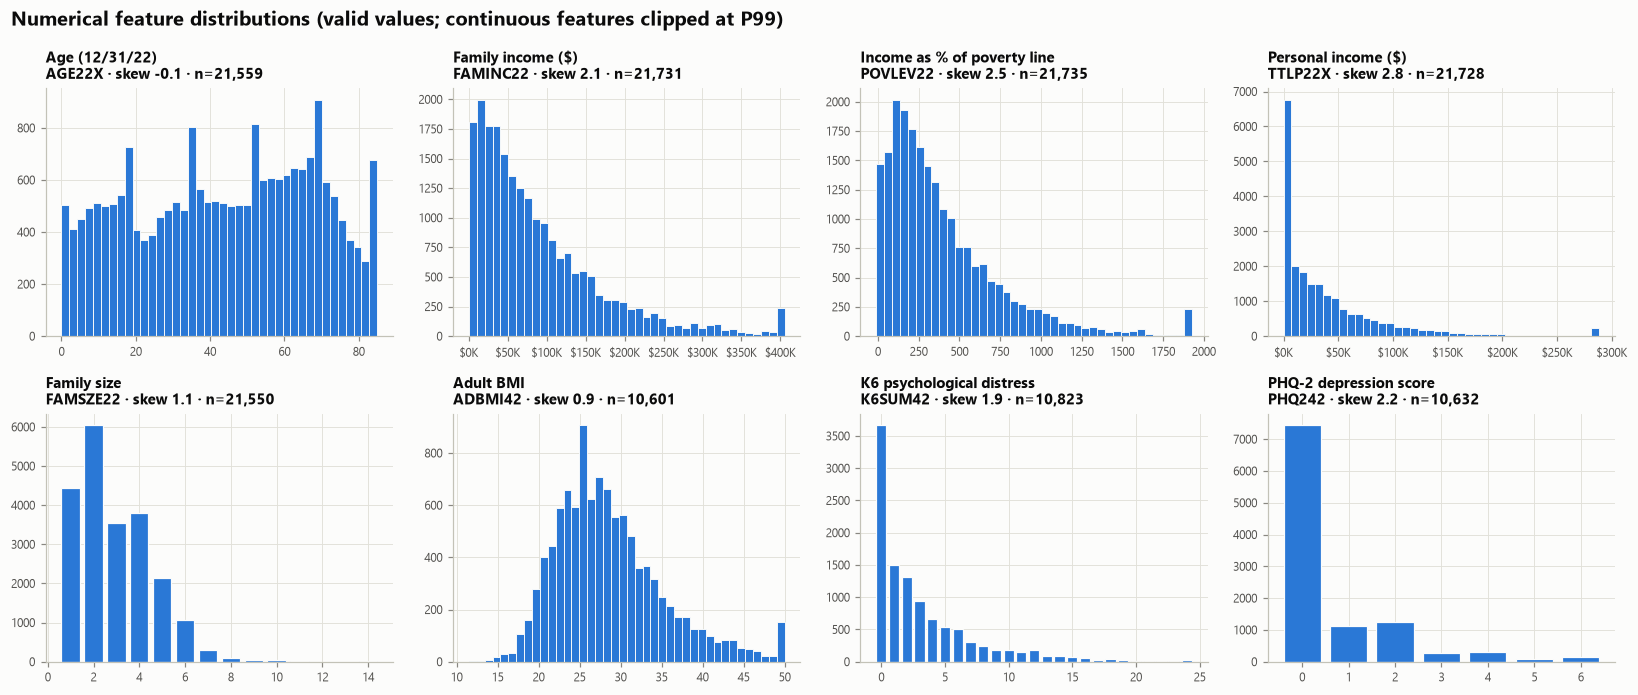

In [15]:
plot_num = ["AGE22X", "FAMINC22", "POVLEV22", "TTLP22X", "FAMSZE22", "ADBMI42", "K6SUM42", "PHQ242"]
fig, axes = plt.subplots(2, 4, figsize=(15, 6.4))
for ax, c in zip(axes.ravel(), plot_num):
    v = valid(c)
    discrete = v.nunique() <= 25
    if discrete:
        vc = v.value_counts().sort_index()
        ax.bar(vc.index, vc.values, color=LOW_COST_COLOR, width=0.8, edgecolor=SURFACE, linewidth=0.8)
    else:
        ax.hist(v.clip(upper=v.quantile(.99)), bins=40, color=LOW_COST_COLOR, edgecolor=SURFACE, linewidth=0.6)
    ax.set_title(f"{NUMERIC[c]}\n{c} · skew {v.skew():.1f} · n={len(v):,}", fontsize=10)
    if c in ("FAMINC22", "TTLP22X"):
        ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x/1000:,.0f}K"))
    ax.tick_params(labelsize=8)
fig.suptitle("Numerical feature distributions (valid values; continuous features clipped at P99)",
             x=0.01, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout()
save_fig(fig, "06_numeric_distributions")
plt.show()

#### 📖 What this chart shows (in plain English)
Each small chart shows how the values of one number-type feature are spread across people. Taller bars mean more people have that value.

- **Age:** spread fairly evenly from 0 to 85. The spike at 85 happens because everyone older is recorded as 85.
- **Family income, personal income, poverty level:** most people are on the left (lower amounts) and a long tail stretches to the right. This is called **right-skewed**. Personal income has a big spike at $0, from children and people without earnings.
- **Family size:** most families have 1–4 people.
- **BMI:** a bell shape centred around 27.
- **K6 distress and PHQ-2 depression scores:** most people score 0 (no symptoms).

**What it means for us:** the income features are lopsided. For some models (logistic regression, KNN, SVM) we will apply a **log transform** to make them more even. Tree-based models don't need this.

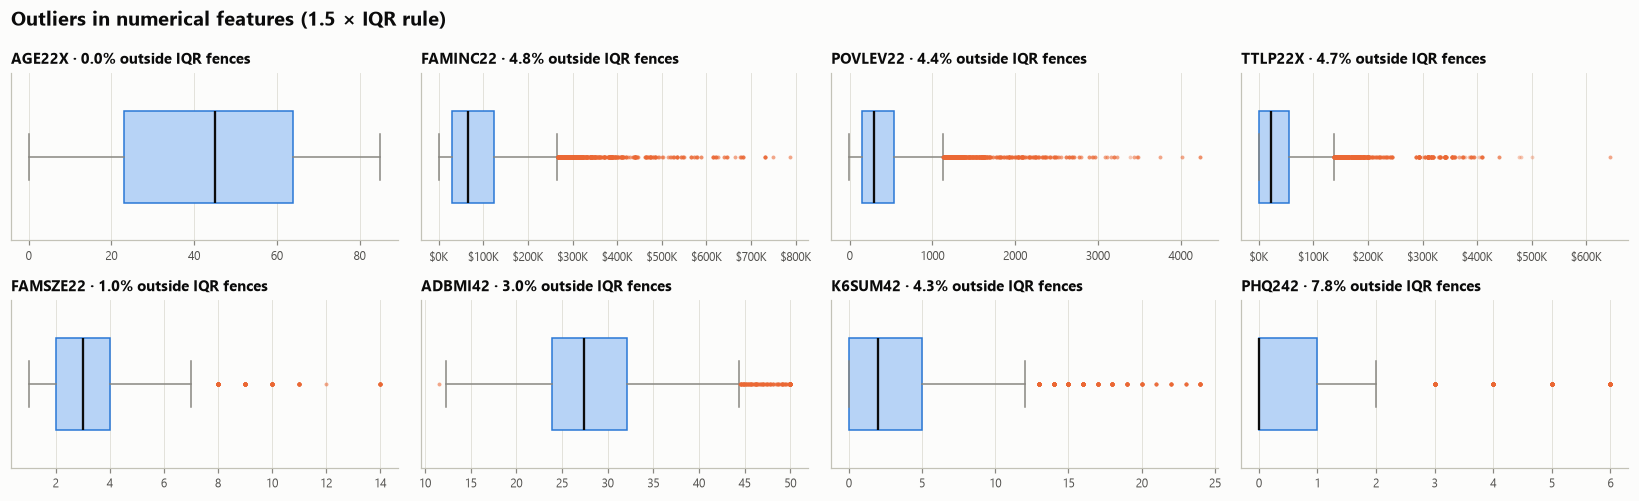

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(15, 4.6))
for ax, c in zip(axes.ravel(), plot_num):
    v = valid(c)
    ax.boxplot(v, orientation="horizontal", widths=0.55, patch_artist=True,
               boxprops=dict(facecolor="#b7d3f6", edgecolor=LOW_COST_COLOR),
               medianprops=dict(color=INK, linewidth=1.5),
               whiskerprops=dict(color=INK_MUTED), capprops=dict(color=INK_MUTED),
               flierprops=dict(marker="o", markersize=2.5, markerfacecolor=HIGH_COST_COLOR,
                               markeredgecolor="none", alpha=0.35))
    ax.set_yticks([])
    ax.set_title(f"{c} · {num_summary.loc[c, 'pct_outliers_IQR']:.1f}% outside IQR fences", fontsize=10)
    if c in ("FAMINC22", "TTLP22X"):
        ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x/1000:,.0f}K"))
    ax.tick_params(labelsize=8)
fig.suptitle("Outliers in numerical features (1.5 × IQR rule)", x=0.01, ha="left",
             fontsize=13, fontweight="bold")
fig.tight_layout()
save_fig(fig, "07_numeric_outliers")
plt.show()

#### 📖 What this chart shows (in plain English)
The same features as boxplots. The box holds the middle half of people, and the **orange dots are values unusually far from the rest**.

- **Age** has no outliers.
- **Incomes** have about **5%** outliers, all on the high side (rich households).
- The **scores** (BMI, K6, PHQ-2) have a few high values, meaning people with more symptoms.

**What it means for us:** these outliers are **real people, not errors**. We won't delete them. For models that are sensitive to extreme values, we will soften them (log transform or capping).

- **Age** is spread almost evenly from 0 to 85 (top-coded at 85). It has no outliers and the strongest numeric link to spending (ρ ≈ 0.42).
- **Incomes** are right-skewed with a long upper tail (~5% IQR outliers, real values) and a spike at $0. **Decision:** apply `log1p` or winsorize for linear and distance-based models. Trees need no transform.
- `FAMINC22` and `POVLEV22` are the same information (poverty % = family income ÷ poverty line). See Section 7.
- `FAMSZE22` correlates *negatively* with spending (ρ ≈ −0.34). Large families are mostly children and young adults.
- BMI, K6 and PHQ-2 have only ~49% valid values (SAQ). Their links to spending are weak, which supports dropping them.

## 5. Categorical features

In [17]:
def labelled(col):
    m = {**RESERVED_CODES, **LABELS.get(col, YES_NO if col in FLAGS else {})}
    if col == "REGION22":
        m[-1] = "Not in scope 12/31"
    return df[col].map(lambda x: m.get(x, str(x)))

rows = []
for c in {**NOMINAL, **ORDINAL, **FLAGS}:
    vc = labelled(c).value_counts(normalize=True) * 100
    rows.append({"feature": c, "n_categories": len(vc), "dominant": vc.index[0],
                 "dominant_pct": vc.iloc[0], "n_rare_(<1%)": int((vc < 1).sum()),
                 "rare_categories": ", ".join(vc[vc < 1].index)})
cat_summary = pd.DataFrame(rows).set_index("feature").round(1)
cat_summary.to_csv(RESULTS / "eda_categorical_summary.csv")
display(cat_summary)

,n_categories,dominant,dominant_pct,n_rare_(<1%),rare_categories
feature,,,,,
SEX,2,Female,52.8,0,
RACETHX,5,NH White,54.5,0,
REGION22,5,South,38.3,1,Not in scope 12/31
MARRY22X,8,Married,38.5,2,"Refused, Don't know"
HIDEG,10,High school,30.6,2,"Don't know, Refused"
INSCOV22,3,Any private,58.5,0,
EMPST53,8,Employed,45.4,4,"Refused, Job to return to, Cannot be computed,..."
HAVEUS42,5,Yes,71.5,0,
BORNUSA,5,Yes,83.1,3,"Inapplicable, Refused, Don't know"


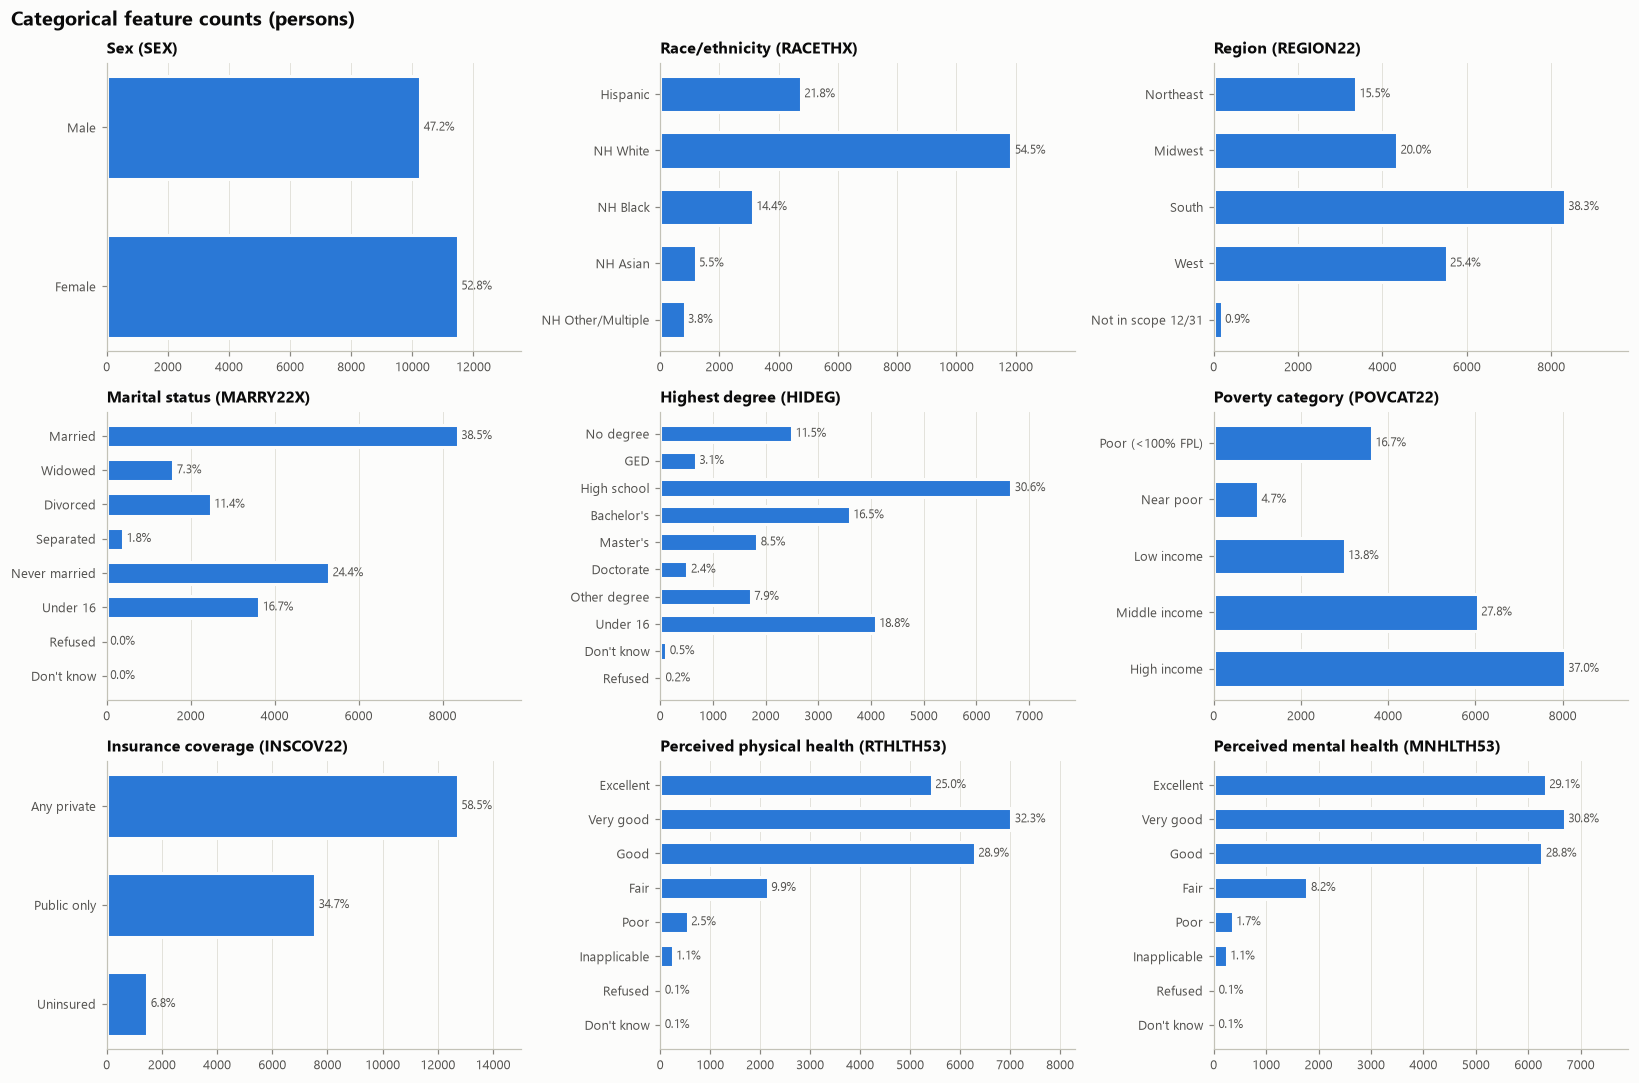

In [18]:
plot_cat = ["SEX", "RACETHX", "REGION22", "MARRY22X", "HIDEG", "POVCAT22", "INSCOV22", "RTHLTH53", "MNHLTH53"]
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, c in zip(axes.ravel(), plot_cat):
    order = [LABELS[c][k] for k in sorted(LABELS[c])]
    vc = labelled(c).value_counts()
    vc = vc.reindex(order + [i for i in vc.index if i not in order])
    ax.barh(vc.index, vc.values, color=LOW_COST_COLOR, height=0.65, edgecolor=SURFACE, linewidth=2)
    for y, n in enumerate(vc.values):
        ax.text(n + vc.max() * 0.01, y, f"{n / len(df):.1%}", va="center", fontsize=8, color=INK_SECONDARY)
    ax.invert_yaxis()
    ax.grid(axis="y", visible=False)
    ax.set_xlim(0, vc.max() * 1.18)
    ax.tick_params(labelsize=8.5)
    ax.set_title(f"{CANDIDATES[c]} ({c})", fontsize=10.5)
fig.suptitle("Categorical feature counts (persons)", x=0.01, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout()
save_fig(fig, "08_categorical_counts")
plt.show()

#### 📖 What this chart shows (in plain English)
Each chart counts how many people fall into each category of a feature, with the percentage printed next to each bar.

- **Sex:** about half and half.
- **Race/ethnicity:** Non-Hispanic White is the largest group (55%).
- **Region:** the South is the largest (38%).
- **Insurance:** 59% have private insurance, 35% public only (Medicare/Medicaid), 7% are uninsured.
- **Self-rated health:** most people say Excellent, Very good or Good. Few say Poor.
- **Marital status / degree:** "Under 16" is a large group. It stands for children, not a real answer.

**What it means for us:** some categories are **very small** (for example "Refused" at 0.1%). We will merge those into "missing". We also note that "Under 16" repeats information we already get from age.

- The samples are reasonably balanced on sex and region. Race/ethnicity is dominated by NH White (~55%).
- **Rare categories** come mainly from refused/don't-know codes (<1%) and a few small levels (Separated, Doctorate, GED). **Decision:** merge the `-7/-8` levels into missing, then impute. Tree models can keep the small real levels, and one-hot encoding handles them.
- "Under 16" levels in `MARRY22X` and `HIDEG` duplicate information already in age. That is acceptable, but it is a correlation to be aware of.

## 6. Features vs. target

For each feature: the **share of people who are high-cost** in each category. The dashed line is the overall rate (20%).

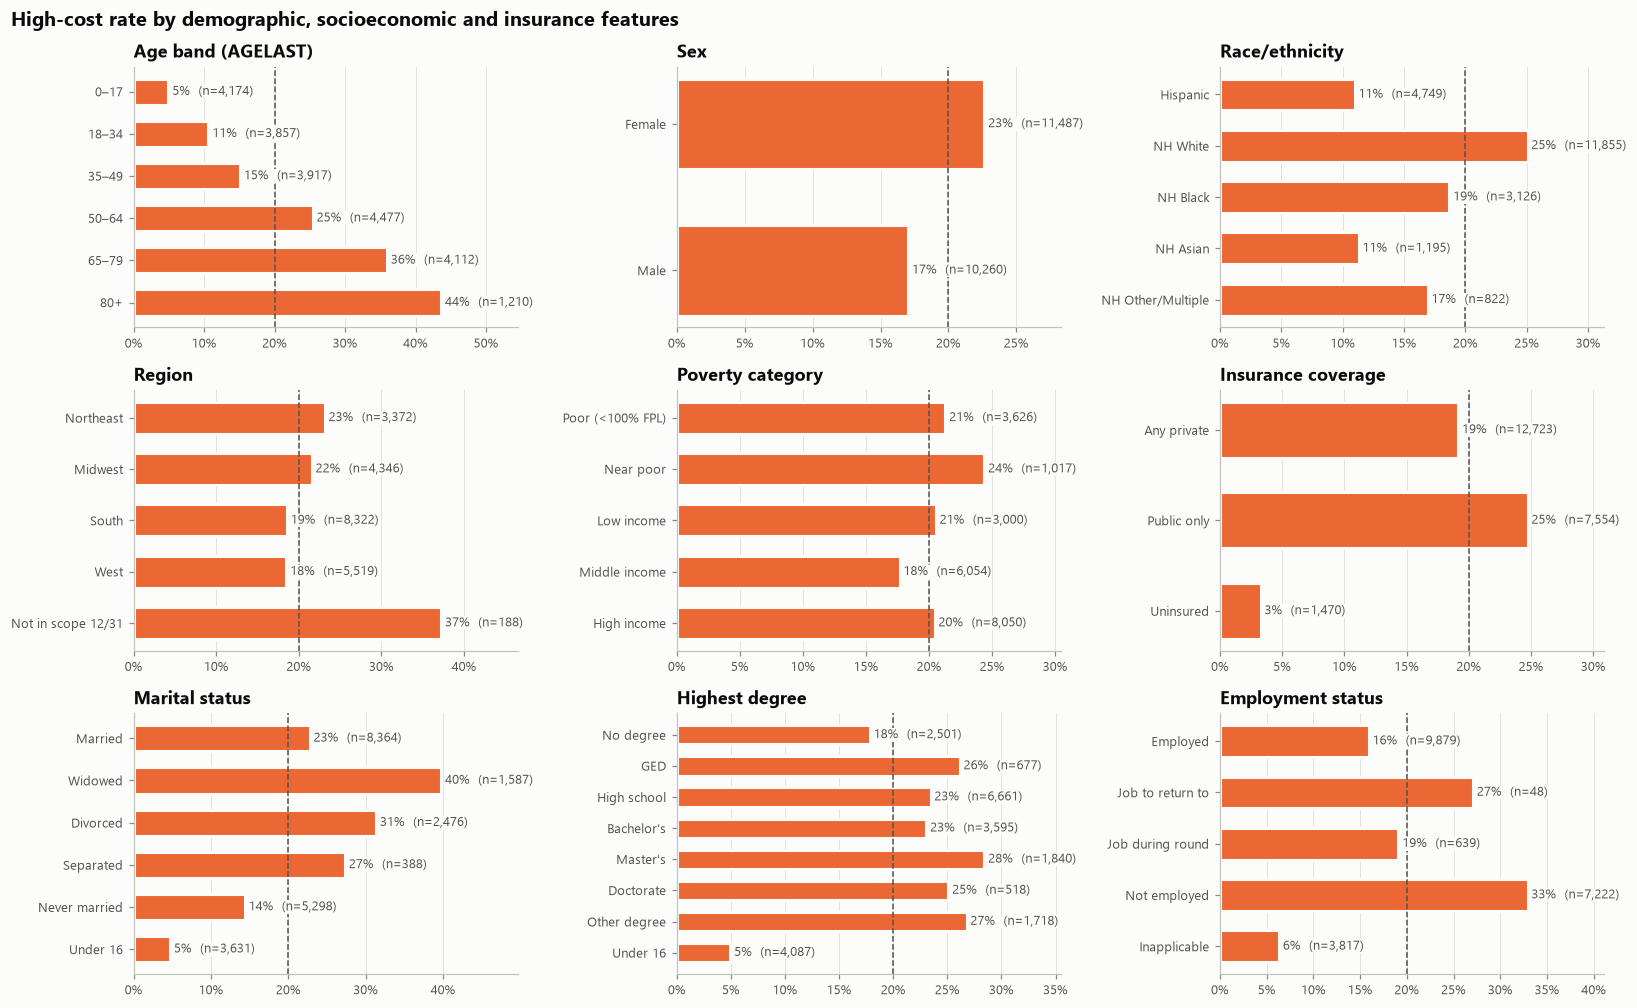

In [19]:
df["AGE_BAND"] = pd.cut(df["AGELAST"], [-1, 17, 34, 49, 64, 79, 120],
                        labels=["0–17", "18–34", "35–49", "50–64", "65–79", "80+"])
ADULT_CONDITIONS = [c for c in CONDITIONS if c != "ADHDADDX"]
df["N_CONDITIONS"] = (df[ADULT_CONDITIONS] == 1).sum(axis=1)
df["N_CONDITIONS_CAP"] = df["N_CONDITIONS"].clip(upper=6).map(lambda n: "6+" if n == 6 else str(n))
df["ANY_LIMITATION"] = (df[list(LIMITATIONS)] == 1).any(axis=1).map({True: "Yes", False: "No"})

def rate_table(col, order=None):
    lab = df[col].astype(str) if col in ("AGE_BAND", "N_CONDITIONS_CAP", "ANY_LIMITATION") else labelled(col)
    g = df.groupby(lab, observed=True)["HIGH_COST"].agg(rate="mean", n="size")
    g["rate"] *= 100
    if order: g = g.reindex([o for o in order if o in g.index])
    return g[g.n >= 30]  # hide tiny code levels to avoid noisy rates

rate_rows = []
def plot_rates(panels, fname, title, ncols=3):
    nrows = int(np.ceil(len(panels) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.1 * nrows))
    for ax, (col, name, order) in zip(axes.ravel(), panels):
        g = rate_table(col, order)
        rate_bar(ax, g.index, g.rate, g.n, overall_rate, title=name)
        ax.tick_params(labelsize=8.5)
        ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
        rate_rows.extend({"feature": col, "level": i, "high_cost_rate": round(r.rate, 1), "n": int(r.n)}
                         for i, r in g.iterrows())
    for ax in axes.ravel()[len(panels):]:
        ax.set_visible(False)
    fig.suptitle(title, x=0.01, ha="left", fontsize=13, fontweight="bold")
    fig.tight_layout()
    save_fig(fig, fname)
    plt.show()

health_order = list(HEALTH.values())
plot_rates([
    ("AGE_BAND", "Age band (AGELAST)", None),
    ("SEX", "Sex", None),
    ("RACETHX", "Race/ethnicity", list(LABELS["RACETHX"].values())),
    ("REGION22", "Region", list(LABELS["REGION22"].values()) + ["Not in scope 12/31"]),
    ("POVCAT22", "Poverty category", list(LABELS["POVCAT22"].values())),
    ("INSCOV22", "Insurance coverage", list(LABELS["INSCOV22"].values())),
    ("MARRY22X", "Marital status", list(LABELS["MARRY22X"].values())),
    ("HIDEG", "Highest degree", list(LABELS["HIDEG"].values())),
    ("EMPST53", "Employment status", list(LABELS["EMPST53"].values()) + ["Inapplicable"]),
], "09_highcost_rate_demographics", "High-cost rate by demographic, socioeconomic and insurance features")

#### 📖 What this chart shows (in plain English)
Each bar shows **what percent of that group are high-cost spenders**. The **dashed line is the overall average (20%)**. Bars past the line mean the group is more likely than average to be high-cost.

- **Age:** the clearest pattern. Only **5%** of children are high-cost, compared with **44%** of people over 80. Older people cost more.
- **Sex:** women (23%) are slightly more likely than men (17%).
- **Race:** Non-Hispanic White people (25%) are higher than Hispanic and Asian people (11%). This is likely related to age and access to care. Race is a **sensitive** feature and must be handled carefully.
- **Insurance:** the **uninsured are only 3%** high-cost. They are not healthier; they **get less care** because they can't afford it.
- **Poverty level:** almost no difference between rich and poor.
- **"Not in scope 12/31"** (37%): people who died or went into a nursing home during the year. They are a small but very high-cost group.

**What it means for us:** age and insurance matter a lot, and income matters very little.

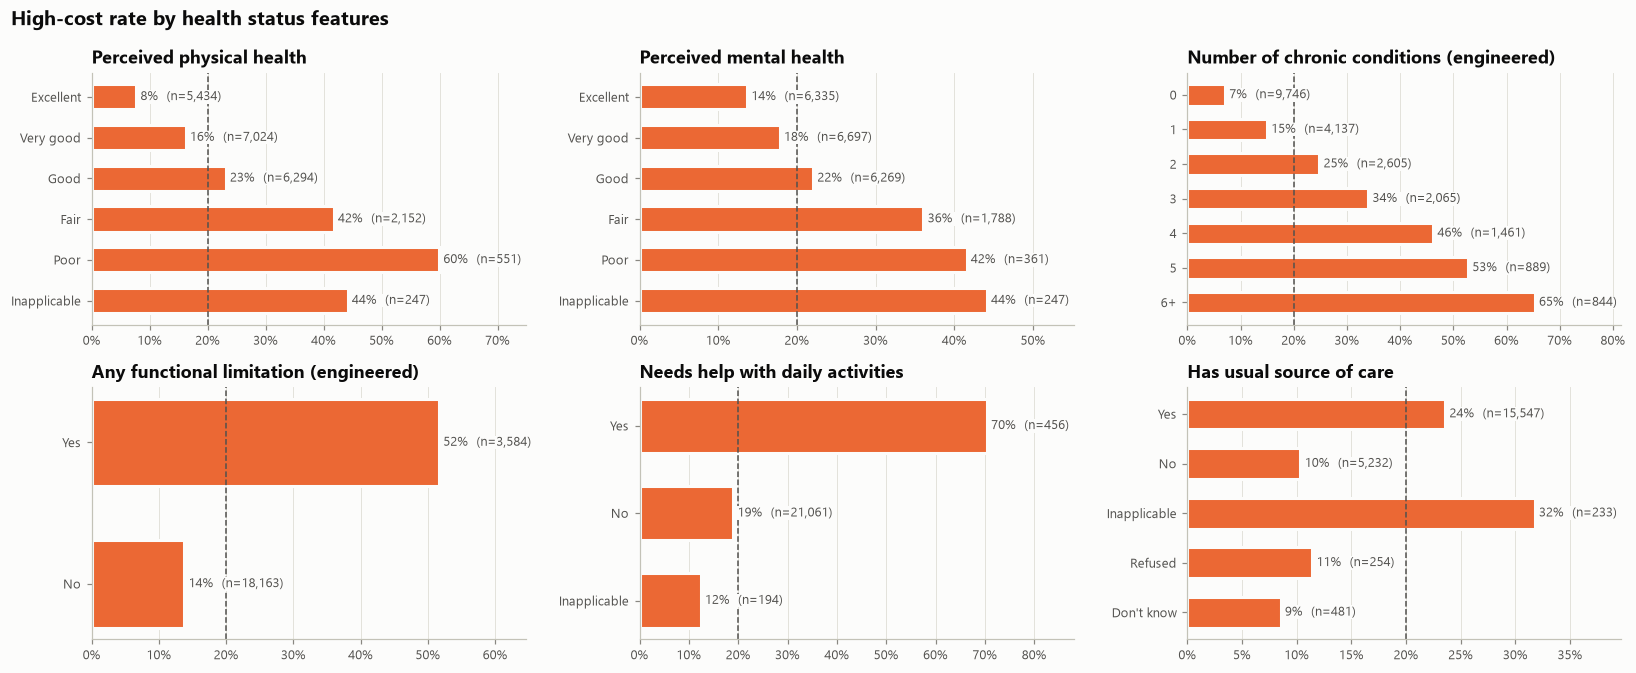

In [20]:
plot_rates([
    ("RTHLTH53", "Perceived physical health", health_order + ["Inapplicable"]),
    ("MNHLTH53", "Perceived mental health", health_order + ["Inapplicable"]),
    ("N_CONDITIONS_CAP", "Number of chronic conditions (engineered)", ["0", "1", "2", "3", "4", "5", "6+"]),
    ("ANY_LIMITATION", "Any functional limitation (engineered)", ["Yes", "No"]),
    ("ADLHLP31", "Needs help with daily activities", ["Yes", "No", "Inapplicable"]),
    ("HAVEUS42", "Has usual source of care", ["Yes", "No", "Inapplicable", "Refused", "Don't know"]),
], "10_highcost_rate_health", "High-cost rate by health status features")

#### 📖 What this chart shows (in plain English)
Same style as before: each bar is the **percent of that group who are high-cost**, and the dashed line is the 20% average.

- **Self-rated physical health:** people who say "Excellent" are **8%** high-cost, while those who say "Poor" are **60%**. How people rate their own health is a strong clue.
- **Number of chronic conditions:** rises steadily from **7%** (no conditions) to **65%** (6 or more conditions). This is the **strongest single signal** we found.
- **Any functional limitation** (trouble walking, working and so on): **52%** vs 14%.
- **Needs help with daily activities** (bathing, dressing): **70%** are high-cost.
- **Has a usual doctor:** 24% vs 10%. People with a regular doctor use more care.

**What it means for us:** **health status is the best predictor of cost**. The features we created ourselves (number of conditions, any limitation) work very well.

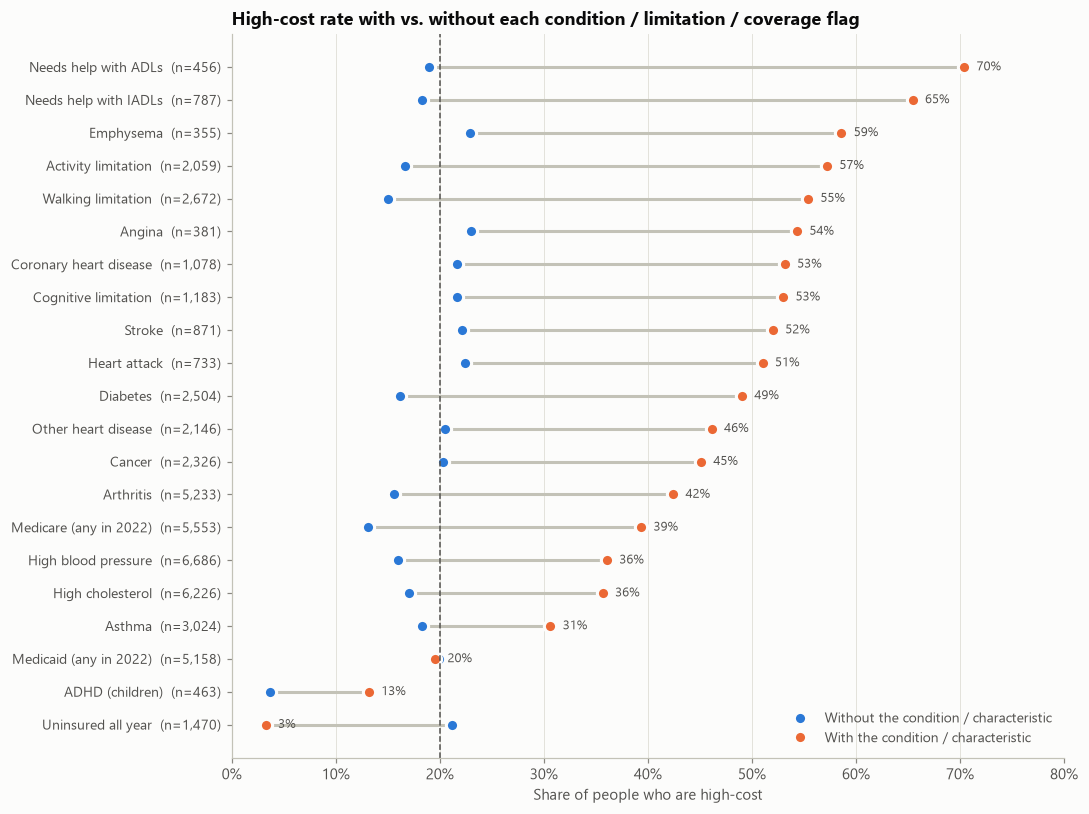

In [21]:
rows = []
for c, name in FLAGS.items():
    yes, no = df.loc[df[c] == 1, "HIGH_COST"], df.loc[df[c] == 2, "HIGH_COST"]
    rows.append({"feature": c, "label": name, "rate_yes": yes.mean() * 100, "rate_no": no.mean() * 100,
                 "n_yes": len(yes), "prevalence_pct": len(yes) / len(df) * 100})
flag_rates = pd.DataFrame(rows).set_index("feature")
flag_rates["lift"] = flag_rates.rate_yes / flag_rates.rate_no
flag_rates = flag_rates.sort_values("rate_yes")
flag_rates.round(2).to_csv(RESULTS / "eda_flag_highcost_rates.csv")

fig, ax = plt.subplots(figsize=(10, 7.5))
y = np.arange(len(flag_rates))
ax.hlines(y, flag_rates.rate_no, flag_rates.rate_yes, color="#c3c2b7", linewidth=2)
ax.plot(flag_rates.rate_no, y, "o", color=LOW_COST_COLOR, markersize=8, markeredgecolor=SURFACE,
        markeredgewidth=2, label="Without the condition / characteristic")
ax.plot(flag_rates.rate_yes, y, "o", color=HIGH_COST_COLOR, markersize=8, markeredgecolor=SURFACE,
        markeredgewidth=2, label="With the condition / characteristic")
ax.axvline(overall_rate, color=INK_SECONDARY, linewidth=1, linestyle="--")
ax.set_yticks(y, [f"{r.label}  (n={r.n_yes:,})" for _, r in flag_rates.iterrows()], fontsize=9)
for yi, r in zip(y, flag_rates.itertuples()):
    ax.text(r.rate_yes + 1.2, yi, f"{r.rate_yes:.0f}%", va="center", fontsize=8.5, color=INK_SECONDARY)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlim(0, 80)
ax.grid(axis="y", visible=False)
ax.legend(loc="lower right", fontsize=9)
ax.set_xlabel("Share of people who are high-cost")
ax.set_title("High-cost rate with vs. without each condition / limitation / coverage flag")
fig.tight_layout()
save_fig(fig, "11_highcost_rate_flags")
plt.show()

#### 📖 What this chart shows (in plain English)
Each row is a yes/no feature, such as "has diabetes".

- The **blue dot** is the high-cost rate for people **without** it.
- The **orange dot** is the high-cost rate for people **with** it.
- The **longer the grey line**, the bigger the difference that feature makes.

**How to read it:** rows are sorted so the strongest effects are at the top.

- **Needing help with daily activities (70%)**, **emphysema (59%)**, and **walking or activity limitations (55–57%)** make a person about 3 times more likely to be high-cost.
- Heart disease, stroke, diabetes and cancer all raise it to roughly **45–54%**.
- **Medicaid** makes no difference: both dots sit on 20%.
- **Uninsured** is the only one that goes the **other way**: 3% with it vs 21% without.

**What it means for us:** almost every health condition clearly raises cost, so these flags are useful model features.

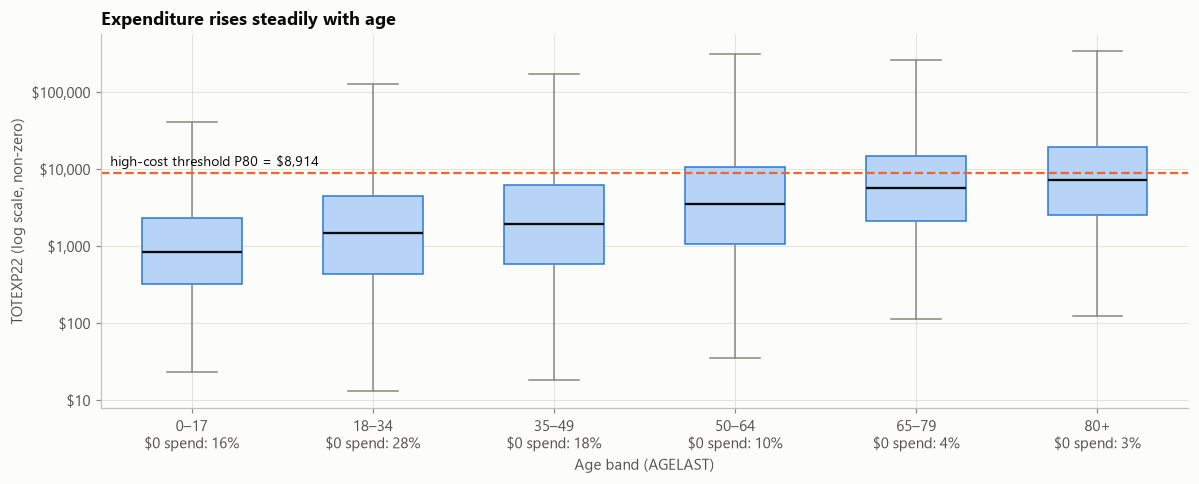

In [22]:
fig, ax = plt.subplots(figsize=(11, 4.5))
bands = df["AGE_BAND"].cat.categories
data = [np.log10(df.loc[(df.AGE_BAND == b) & (df[TARGET_COL] > 0), TARGET_COL]) for b in bands]
parts = ax.boxplot(data, widths=0.55, patch_artist=True, showfliers=False,
                   boxprops=dict(facecolor="#b7d3f6", edgecolor=LOW_COST_COLOR),
                   medianprops=dict(color=INK, linewidth=1.5),
                   whiskerprops=dict(color=INK_MUTED), capprops=dict(color=INK_MUTED))
ax.axhline(np.log10(threshold), color=HIGH_COST_COLOR, linewidth=1.5, linestyle="--")
ax.text(0.55, np.log10(threshold) + 0.05, f"high-cost threshold P80 = ${threshold:,.0f}", color=INK, fontsize=9, va="bottom")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${10**x:,.0f}"))
zero_pct = df.groupby("AGE_BAND", observed=True)[TARGET_COL].apply(lambda s: (s == 0).mean() * 100)
ax.set_xticks(range(1, len(bands) + 1), [f"{b}\n$0 spend: {zero_pct[b]:.0f}%" for b in bands])
ax.set_xlabel("Age band (AGELAST)")
ax.set_ylabel("TOTEXP22 (log scale, non-zero)")
ax.set_title("Expenditure rises steadily with age")
fig.tight_layout()
save_fig(fig, "12_expenditure_by_age")
plt.show()

#### 📖 What this chart shows (in plain English)
Each box shows the spending of one age group, only for people who spent more than $0. The black line is the **median** (the middle person). The **orange dashed line** is our high-cost cut-off ($8,914). The text under each age group shows what percent of that group spent **$0**.

**How to read it:** the boxes climb higher as age increases.

- Children's median spending is about **$800**. People over 80 have a median of about **$7,000**, close to the high-cost line.
- Young adults (18–34) are the most likely to spend nothing (**28%**). Older adults almost always spend something (**3–4%** at $0).

**What it means for us:** **age is a strong, steady predictor**. Older people are much more likely to cross the high-cost line.

### Statistical association with the target

In [23]:
def cramers_v(x, y):
    tab = pd.crosstab(x, y)
    chi2, p, _, _ = stats.chi2_contingency(tab)
    n = tab.to_numpy().sum()
    return chi2, p, np.sqrt(chi2 / (n * (min(tab.shape) - 1)))

rows = []
for c in {**NOMINAL, **ORDINAL, **FLAGS}:
    chi2, p, v = cramers_v(df[c], df["HIGH_COST"])
    rows.append({"feature": c, "label": CANDIDATES[c], "type": "categorical", "chi2": chi2,
                 "p_value": p, "cramers_v": v})
for c in ["N_CONDITIONS", "AGE_BAND", "ANY_LIMITATION"]:
    chi2, p, v = cramers_v(df[c], df["HIGH_COST"])
    rows.append({"feature": c, "label": "engineered", "type": "engineered", "chi2": chi2, "p_value": p, "cramers_v": v})
for c in NUMERIC:
    v = valid(c)
    rows.append({"feature": c, "label": CANDIDATES[c], "type": "numeric",
                 "spearman_vs_TOTEXP22": stats.spearmanr(v, df.loc[v.index, TARGET_COL])[0],
                 "mann_whitney_p": stats.mannwhitneyu(v[df.loc[v.index, "HIGH_COST"] == 1],
                                                      v[df.loc[v.index, "HIGH_COST"] == 0])[1]})
assoc = pd.DataFrame(rows).set_index("feature")
assoc.round(4).to_csv(RESULTS / "eda_feature_target_association.csv")
display(assoc[assoc.type != "numeric"].sort_values("cramers_v", ascending=False)
        [["label", "cramers_v", "p_value"]].round(4).head(20))
display(assoc[assoc.type == "numeric"][["label", "spearman_vs_TOTEXP22", "mann_whitney_p"]]
        .sort_values("spearman_vs_TOTEXP22", key=abs, ascending=False).round(4))

,label,cramers_v,p_value
feature,,,
N_CONDITIONS,engineered,0.4126,0.0
ANY_LIMITATION,engineered,0.3512,0.0
WLKLIM31,Walking limitation,0.3312,0.0
ARTHDX,Arthritis,0.3311,0.0
ACTLIM31,Activity limitation,0.3065,0.0
AGE_BAND,engineered,0.3049,0.0
RTHLTH53,Perceived physical health,0.2955,0.0
MCARE22,Medicare (any in 2022),0.2886,0.0
HIBPDX,High blood pressure,0.2864,0.0


,label,spearman_vs_TOTEXP22,mann_whitney_p
feature,,,
AGE22X,Age (12/31/22),0.4155,0.0000
DDNWRK22,Work days missed,0.3566,0.0000
FAMSZE22,Family size,-0.3365,0.0000
TTLP22X,Personal income ($),0.2020,0.0000
K6SUM42,K6 psychological distress,0.1888,0.0000
PHQ242,PHQ-2 depression score,0.1519,0.0000
POVLEV22,Income as % of poverty line,0.1206,0.9251
ADBMI42,Adult BMI,0.0734,0.0000
FAMINC22,Family income ($),0.0137,0.0000


**What drives high cost (association, not causation):**

1. **Health burden is the dominant signal.** The high-cost rate rises from ~7% with no chronic conditions to ~65% with 6+. Fair/poor physical health, needing help with daily activities, and serious conditions (emphysema, heart disease, stroke, diabetes, cancer) each roughly double or triple the rate.
2. **Age** gives a steady gradient, from ~5% (0–17) to ~44% (80+).
3. **Insurance access.** The uninsured are rarely high-cost (~3%). This reflects *less care received*, not better health, and the model will learn it as a real pattern of the healthcare system.
4. **Socioeconomic variables are weak.** The poverty category is almost flat, and income has little correlation with spending.
5. **Race/ethnicity** differs (NH White ~25% vs Hispanic/Asian ~11%). This is partly age and access to care. It is a **fairness-sensitive** feature and must be justified or tested with and without it.

## 7. Correlation and redundancy

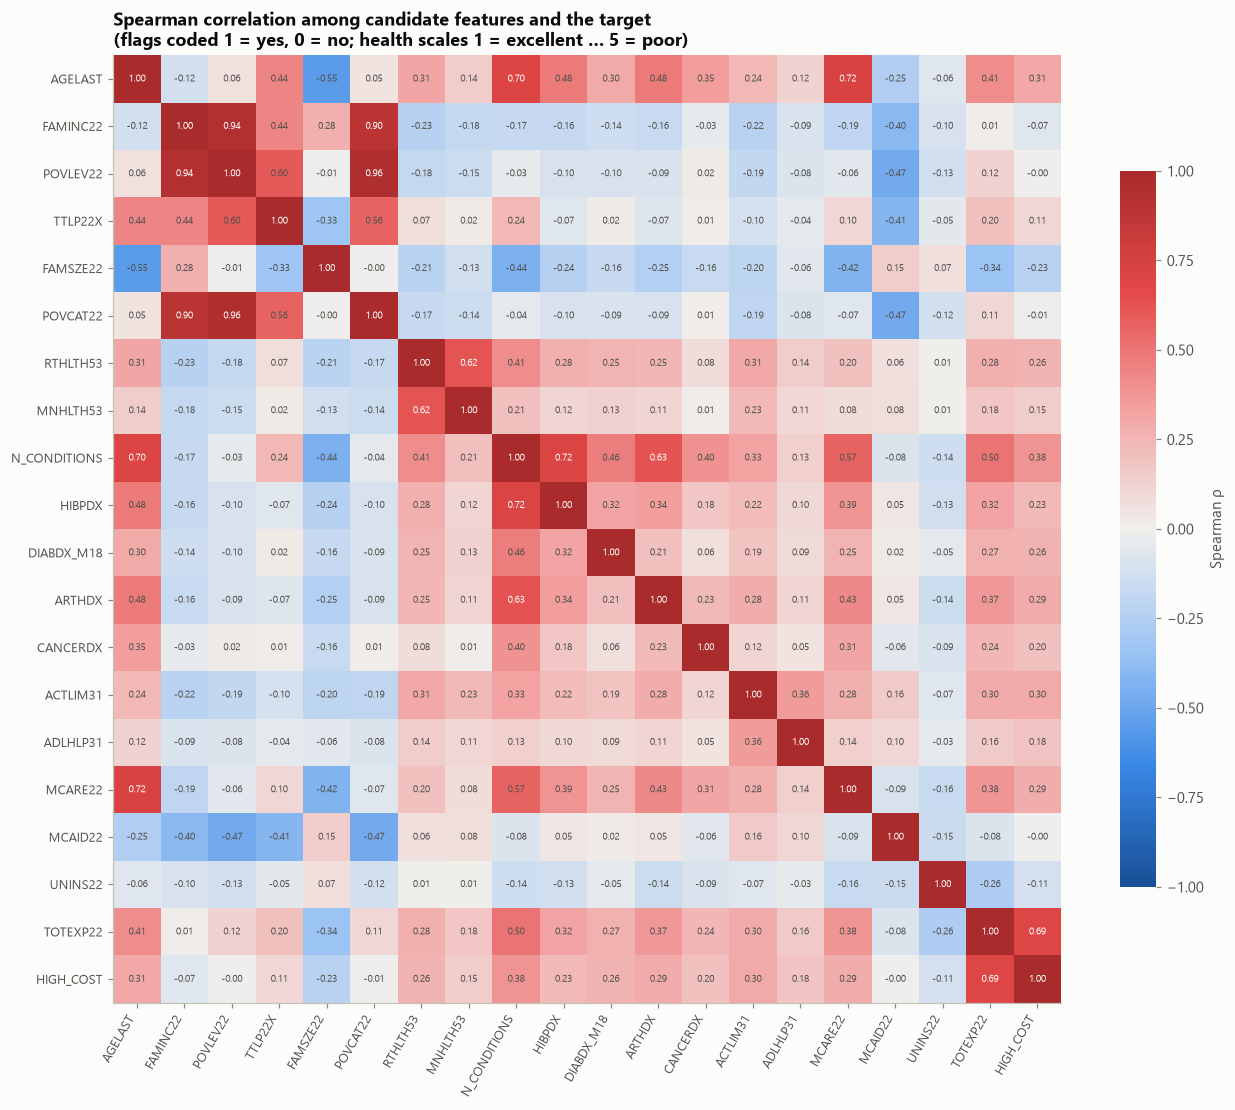

In [24]:
def as_numeric(col):
    v = df[col].astype(float)
    if col in FLAGS:
        return v.map({1: 1.0, 2: 0.0})
    if col in SIGNED_INCOME_COLS:
        return v.where(v > -15)
    return v.where(v >= 0)

corr_cols = ["AGELAST", "FAMINC22", "POVLEV22", "TTLP22X", "FAMSZE22", "POVCAT22", "RTHLTH53", "MNHLTH53",
             "N_CONDITIONS", "HIBPDX", "DIABDX_M18", "ARTHDX", "CANCERDX", "ACTLIM31", "ADLHLP31",
             "MCARE22", "MCAID22", "UNINS22", "TOTEXP22", "HIGH_COST"]
M = pd.DataFrame({c: (df[c] if c in ("N_CONDITIONS", "HIGH_COST", "AGELAST", "TOTEXP22") else as_numeric(c))
                  for c in corr_cols})
corr = M.corr(method="spearman")
corr.round(3).to_csv(RESULTS / "eda_spearman_correlation.csv")

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, cmap=DIVERGING, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=60, ha="right", fontsize=8.5)
ax.set_yticks(range(len(corr)), corr.index, fontsize=8.5)
ax.grid(False)
for i in range(len(corr)):
    for j in range(len(corr)):
        val = corr.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=6.8,
                color="#ffffff" if abs(val) > 0.6 else INK_SECONDARY)
cb = fig.colorbar(im, ax=ax, shrink=0.75)
cb.outline.set_visible(False)
cb.set_label("Spearman ρ")
ax.set_title("Spearman correlation among candidate features and the target\n"
             "(flags coded 1 = yes, 0 = no; health scales 1 = excellent … 5 = poor)")
fig.tight_layout()
save_fig(fig, "13_correlation_heatmap")
plt.show()

#### 📖 What this chart shows (in plain English)
This grid shows how strongly **every pair of features moves together**. It uses Spearman correlation, a number from −1 to +1.

- **Dark red (close to +1):** when one goes up, the other goes up.
- **Dark blue (close to −1):** when one goes up, the other goes down.
- **White (close to 0):** no relationship.

**How to read it:** find a feature on the left and another along the bottom, and the square where they meet shows their relationship.

Things to notice:
- **Family income, poverty level and poverty category** are almost the same thing (0.90–0.96). We only need **one** of them.
- **Age and Medicare** are strongly linked (0.72), because Medicare is mainly for people over 65.
- **Age and number of conditions** (0.70): older people have more conditions.
- Looking at the bottom rows (**TOTEXP22** and **HIGH_COST**), the features most related to cost are **number of conditions (0.50)**, **age (0.41)** and **Medicare (0.38)**. Income is near **0**.

**What it means for us:** we will **remove duplicate features** so the model isn't confused by the same information twice. This matters most for logistic regression and Naive Bayes.

In [25]:
pairs = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()
pairs = pairs.drop([p for p in pairs.index if "TOTEXP22" in p or "HIGH_COST" in p])
print("Most correlated feature pairs (|ρ| ≥ 0.5):")
print(pairs[pairs.abs() >= 0.5].sort_values(key=abs, ascending=False).round(3).to_string())
agree = ((df["MCARE22"] == 1) == (df["AGELAST"] >= 65)).mean()
print(f"\nMCARE22 == (age ≥ 65) for {agree:.1%} of persons")

Most correlated feature pairs (|ρ| ≥ 0.5):
POVLEV22      POVCAT22        0.959
FAMINC22      POVLEV22        0.937
              POVCAT22        0.897
AGELAST       MCARE22         0.719
N_CONDITIONS  HIBPDX          0.716
AGELAST       N_CONDITIONS    0.700
N_CONDITIONS  ARTHDX          0.632
RTHLTH53      MNHLTH53        0.623
POVLEV22      TTLP22X         0.597
N_CONDITIONS  MCARE22         0.568
TTLP22X       POVCAT22        0.565
AGELAST       FAMSZE22       -0.552

MCARE22 == (age ≥ 65) for 95.6% of persons


**Decisions (redundancy):**

- `FAMINC22` ↔ `POVLEV22` (ρ ≈ 0.94) ↔ `POVCAT22`: all the same information. **Keep `POVLEV22`** (log-transformed, adjusted for family size) and drop the other two, or keep `POVCAT22` for simple models.
- `MCARE22` matches "age ≥ 65" for about 96% of people. It adds little beyond age. It can be kept for tree models (it captures under-65 disability Medicare), but expect it to share importance with age.
- `N_CONDITIONS` correlates strongly with age (ρ ≈ 0.7) and with each individual condition flag. This is fine for tree-based models. For Naive Bayes, whose features are assumed independent, and for reading Logistic Regression coefficients, use either the count **or** the individual flags.
- Physical and mental self-rated health are correlated (ρ ≈ 0.6) but measure different things. Both are kept.

## 8. Target leakage check

A feature *leaks* if it contains the answer rather than predicting it.

Expenditure / payment / charge columns: 279  →  EXCLUDE (TOTEXP22 is their sum)


,spearman_vs_TOTEXP22,high_cost_rate_if_0,high_cost_rate_if_>0
OBTOTV22,0.76,2.99,25.75
OBDRV22,0.68,4.71,28.60
OPTOTV22,0.49,11.62,45.23
OPDRV22,0.40,14.02,49.46
ERTOT22,0.37,14.54,53.48
IPDIS22,0.37,15.19,87.61
IPNGTD22,0.37,15.19,87.61
DVTOT22,0.36,16.74,24.06
HHTOTD22,0.22,17.13,75.92
HHAGD22,0.22,17.46,81.68


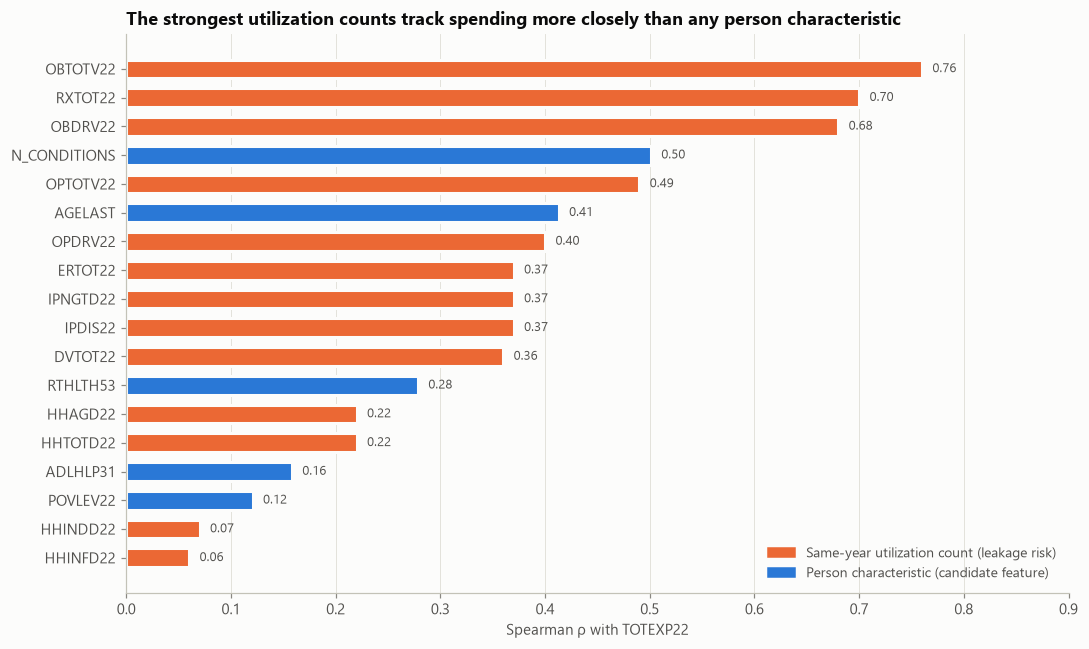

In [26]:
exp_cols = expenditure_columns(df)
print(f"Expenditure / payment / charge columns: {len(exp_cols)}  →  EXCLUDE (TOTEXP22 is their sum)")

top_person = assoc[assoc.type == "numeric"]["spearman_vs_TOTEXP22"].abs().max()
util = pd.DataFrame({
    "spearman_vs_TOTEXP22": [stats.spearmanr(df[c], df[TARGET_COL])[0] for c in UTILIZATION_COLS],
    "high_cost_rate_if_0": [df.loc[df[c] == 0, "HIGH_COST"].mean() * 100 for c in UTILIZATION_COLS],
    "high_cost_rate_if_>0": [df.loc[df[c] > 0, "HIGH_COST"].mean() * 100 for c in UTILIZATION_COLS],
}, index=UTILIZATION_COLS).round(2)
util.to_csv(RESULTS / "eda_utilization_leakage.csv")
display(util)

compare = pd.concat([
    util["spearman_vs_TOTEXP22"].rename("rho").to_frame().assign(kind="Same-year utilization count"),
    pd.Series({"AGELAST": stats.spearmanr(df.AGELAST, df[TARGET_COL])[0],
               "N_CONDITIONS": stats.spearmanr(df.N_CONDITIONS, df[TARGET_COL])[0],
               "RTHLTH53": corr.loc["RTHLTH53", "TOTEXP22"],
               "ADLHLP31": abs(corr.loc["ADLHLP31", "TOTEXP22"]),
               "POVLEV22": corr.loc["POVLEV22", "TOTEXP22"]}).rename("rho").to_frame()
      .assign(kind="Person characteristic"),
]).sort_values("rho")

fig, ax = plt.subplots(figsize=(10, 6))
colors = [HIGH_COST_COLOR if k.startswith("Same") else LOW_COST_COLOR for k in compare.kind]
ax.barh(compare.index, compare.rho, color=colors, height=0.65, edgecolor=SURFACE, linewidth=2)
for y, r in enumerate(compare.rho):
    ax.text(r + 0.01, y, f"{r:.2f}", va="center", fontsize=8.5, color=INK_SECONDARY)
ax.grid(axis="y", visible=False)
ax.set_xlim(0, 0.9)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=HIGH_COST_COLOR, label="Same-year utilization count (leakage risk)"),
                   Patch(color=LOW_COST_COLOR, label="Person characteristic (candidate feature)")],
          loc="lower right", fontsize=9)
ax.set_xlabel("Spearman ρ with TOTEXP22")
ax.set_title("The strongest utilization counts track spending more closely than any person characteristic")
fig.tight_layout()
save_fig(fig, "14_leakage_utilization")
plt.show()

#### 📖 What this chart shows (in plain English)
This compares two kinds of features by how closely they track total spending (higher bar = closer link):

- **Orange:** how much care a person **used** in 2022, such as the number of doctor visits (`OBTOTV22`), prescriptions (`RXTOT22`) or hospital stays (`IPDIS22`).
- **Blue:** **who the person is**: their age, health conditions and self-rated health.

**What it shows:** doctor visits (0.76) and prescriptions (0.70) are linked to spending more strongly than any personal feature.

**Why that is a problem (data leakage):** spending *is* the bill for those visits and prescriptions. Using "number of doctor visits" to predict "money spent on doctor visits" is like predicting a restaurant bill from the number of dishes ordered. It looks accurate, but it is **cheating**, and it can't warn us about anyone **in advance**.

**What it means for us:** our main model will **leave out** these orange features and predict cost only from **who the person is** (blue-type features). We may run one extra experiment *with* them, just to show how leakage makes results look falsely good.

Utilization counts (office visits, prescriptions, hospital stays) are the *events whose payments add up to `TOTEXP22`*. For example, ~88% of people with any inpatient stay are high-cost. Using them turns the task into "people who used a lot of care spent a lot", which is circular and of no use for **risk assessment**.

**Decision (leakage):**

| Excluded | Reason |
|---|---|
| 279 expenditure, payment and charge columns | Direct components of the target |
| Same-year utilization counts (`OBTOTV22`, `RXTOT22`, `IPDIS22`, `ERTOT22`…) | Measure the same events as the target. Excluded from the main model and kept for an optional *with-utilization* experiment that demonstrates the leakage effect |
| IDs, survey weights and design variables | Not person characteristics |
| Constant columns | No information |

## 9. EDA decisions summary

In [27]:
decisions = {
    "problem": "Binary classification: high-cost vs low-cost healthcare user (2022)",
    "population": "PERWT22F > 0",
    "n_persons": int(len(df)),
    "target": {"source": "TOTEXP22", "rule": "HIGH_COST = TOTEXP22 >= P80 of the training split",
               "percentile": THRESHOLD_Q, "p80_full_population_usd": round(float(threshold), 2),
               "positive_rate": round(float(df.HIGH_COST.mean()), 4)},
    "exclude_leakage": {"expenditure_columns": exp_cols, "utilization_columns": UTILIZATION_COLS},
    "exclude_other": {"weights_design": WEIGHT_DESIGN_COLS,
                      "sparse_or_skip_pattern": ["ADBMI42", "K6SUM42", "PHQ242", "ADHDADDX", "DDNWRK22"],
                      "redundant": ["FAMINC22", "TTLP22X"]},
    "candidate_features": {
        "numeric": ["AGELAST", "POVLEV22", "FAMSZE22"],
        "nominal": ["SEX", "RACETHX", "REGION22", "MARRY22X", "HIDEG", "INSCOV22", "EMPST53", "HAVEUS42", "BORNUSA"],
        "ordinal": ["POVCAT22", "RTHLTH53", "MNHLTH53", "OFTSMK53"],
        "flags": [c for c in FLAGS if c != "ADHDADDX"],
        "engineered": ["N_CONDITIONS", "ANY_LIMITATION", "AGE_BAND", "OUT_OF_SCOPE_1231"],
    },
    "reserved_code_handling": {
        "-1": "structural: keep as its own category (e.g. 'not asked - child'); never impute",
        "-7/-8/-15": "true missing: impute inside the pipeline, fitted on training data only",
        "signed income": "negative values in income columns are real, not codes",
    },
    "transforms": "log1p for income/poverty level in linear & distance models; none for trees",
    "outliers": "TOTEXP22 tail is genuine; do not remove",
    "imbalance": "80/20: start with class_weight; SMOTE only inside CV folds if recall is poor",
    "metrics": ["ROC-AUC", "PR-AUC", "F1 (high-cost)", "Recall (high-cost)", "Precision", "Confusion matrix"],
    "fairness_note": "RACETHX is sensitive; compare models with and without it",
}
(RESULTS / "eda_decisions.json").write_text(json.dumps(decisions, indent=2))
print(json.dumps({k: v for k, v in decisions.items() if k != "exclude_leakage"}, indent=2))

{
  "problem": "Binary classification: high-cost vs low-cost healthcare user (2022)",
  "population": "PERWT22F > 0",
  "n_persons": 21747,
  "target": {
    "source": "TOTEXP22",
    "rule": "HIGH_COST = TOTEXP22 >= P80 of the training split",
    "percentile": 0.8,
    "p80_full_population_usd": 8913.6,
    "positive_rate": 0.2
  },
  "exclude_other": {
    "weights_design": [
      "PERWT22F",
      "FAMWT22F",
      "FAMWT22C",
      "SAQWT22F",
      "DIABW22F",
      "VARSTR",
      "VARPSU"
    ],
    "sparse_or_skip_pattern": [
      "ADBMI42",
      "K6SUM42",
      "PHQ242",
      "ADHDADDX",
      "DDNWRK22"
    ],
    "redundant": [
      "FAMINC22",
      "TTLP22X"
    ]
  },
  "candidate_features": {
    "numeric": [
      "AGELAST",
      "POVLEV22",
      "FAMSZE22"
    ],
    "nominal": [
      "SEX",
      "RACETHX",
      "REGION22",
      "MARRY22X",
      "HIDEG",
      "INSCOV22",
      "EMPST53",
      "HAVEUS42",
      "BORNUSA"
    ],
    "ordinal": [
      "PO

| # | Decision |
|---|---|
| 1 | **Classification is justified.** Spending is highly concentrated (top 20% hold ~80%) and clear risk gradients exist. |
| 2 | **Target:** `HIGH_COST = TOTEXP22 ≥ P80` (≈ $8.9K), computed on the training split. Classes are 80/20. |
| 3 | **Population:** `PERWT22F > 0` (21,747 persons). |
| 4 | **Leakage:** exclude all 279 expenditure columns and the same-year utilization counts from the main model. |
| 5 | **Reserved codes:** `-1` becomes its own category. `-7/-8/-15` are imputed inside the pipeline. Negative income values are real. |
| 6 | **Drop:** SAQ items (BMI, K6, PHQ-2), `ADHDADDX`, `DDNWRK22` (sparse), redundant income columns, constant columns. |
| 7 | **Engineer:** chronic-condition count, any functional limitation, age band, out-of-scope-at-year-end flag. |
| 8 | **Transforms:** `log1p` for skewed income in linear and distance models. Keep target outliers. |
| 9 | **Imbalance:** `class_weight` first. SMOTE only inside CV folds, never on test data. |
| 10 | **Metrics:** ROC-AUC, PR-AUC, F1 and recall for the high-cost class, not accuracy alone. |

Next: `03_data_preprocessing.ipynb`. Build the train/test split and a scikit-learn pipeline that implements these decisions.